# Credit card fraud detection

**Evaluation focus:** Because this is an extremely imbalanced fraud-detection problem, PR-AUC is used as the primary model-development metric for comparing and tuning models, because it evaluates the precision–recall trade-off across thresholds. However, the practical objective is to detect as many fraudulent transactions as possible, so recall is given greater importance when interpreting the final deployment choice, while precision and false positives are also considered.

## Step 1 : Project environment & dependency setup
**Objective:** Import the core libraries used throughout the project and fix `RANDOM_STATE = 42` so that splitting, resampling and model training are reproducible. Libraries needed only for a specific step are imported in that step.

In [5]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

## Step 2 : Load & verify dataset
**Objective:** Load `creditcard.csv` and check that its structure matches the dataset description (shape, column order, data types and target values) before any cleaning or modelling. Missing values and duplicates are not handled in this step.

In [7]:
df = pd.read_csv("creditcard.csv")
display(df.head())

print("Shape:", df.shape)

expected_columns = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]
print("Columns match expected order:", list(df.columns) == expected_columns)

df.info()

print("Unique values in Class:", df["Class"].unique())
print(df["Class"].value_counts())
print((df["Class"].value_counts(normalize=True) * 100).round(5))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Shape: (284807, 31)
Columns match expected order: True
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20 

----

## Step 3 : Data quality audit & exact deduplication
**Objective:** Check the raw data for missing values and duplicate rows, then remove exact duplicates before splitting so identical transactions cannot appear in both training and test data. The feature-only duplicate check confirms that no identical feature vector appears with conflicting `Class` labels.

In [8]:
print("Total missing values:", df.isnull().sum().sum())
print("Columns with missing values:", (df.isnull().sum() > 0).sum())

duplicate_rows = df.duplicated()
print("Exact duplicate rows to remove:", duplicate_rows.sum())
print("Duplicate rows removed by class:")
print(df[duplicate_rows]["Class"].value_counts())

feature_duplicates = df.drop(columns="Class").duplicated().sum()
print("Feature-only duplicate rows:", feature_duplicates)
print("No conflicting labels:", feature_duplicates == duplicate_rows.sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print(df["Class"].value_counts())
print((df["Class"].value_counts(normalize=True) * 100).round(5))

Total missing values: 0
Columns with missing values: 0
Exact duplicate rows to remove: 1081
Duplicate rows removed by class:
Class
0    1062
1      19
Name: count, dtype: int64
Feature-only duplicate rows: 1081
No conflicting labels: True
Shape after removing duplicates: (283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


-----


## Step 4 : Focused exploratory data analysis
**Objective:** Explore the cleaned data with checks that support modelling decisions: the size of the imbalance (metrics), `Amount` skew (scaler choice), feature spread (scaling) and unusual values (data quality). All analysis is descriptive only. No features are selected or dropped based on these results, and no meanings are given to `V1`–`V28`.

### 4.1 Class distribution

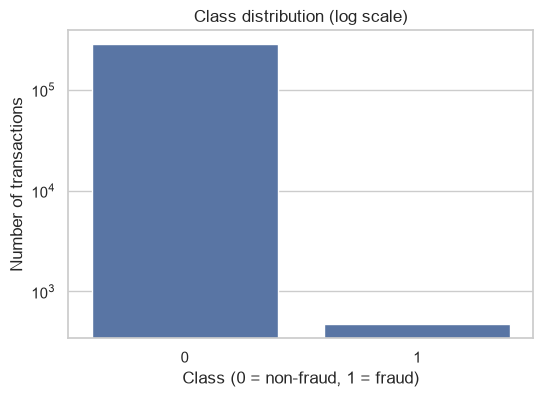

Class
0    283253
1       473
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.yscale("log")
plt.title("Class distribution (log scale)")
plt.xlabel("Class (0 = non-fraud, 1 = fraud)")
plt.ylabel("Number of transactions")
plt.show()

print(df["Class"].value_counts())

### 4.2 Amount

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87
Skewness of Amount: 16.98
Rows with Amount = 0: 1808
Class
0    1783
1      25
Name: count, dtype: int64


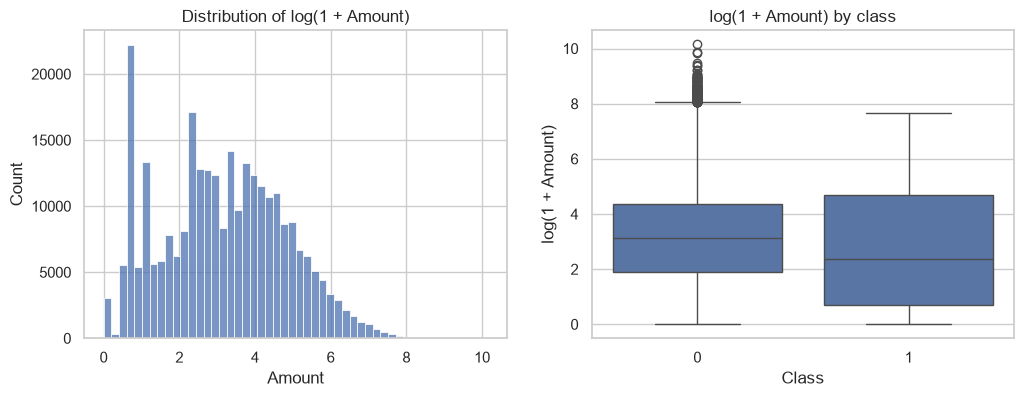

In [10]:
print(df.groupby("Class")["Amount"].describe())
print("Skewness of Amount:", round(df["Amount"].skew(), 2))
print("Rows with Amount = 0:", (df["Amount"] == 0).sum())
print(df[df["Amount"] == 0]["Class"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log1p(df["Amount"]), bins=50, ax=axes[0])
axes[0].set_title("Distribution of log(1 + Amount)")
sns.boxplot(x=df["Class"], y=np.log1p(df["Amount"]), ax=axes[1])
axes[1].set_title("log(1 + Amount) by class")
axes[1].set_ylabel("log(1 + Amount)")
plt.show()

### 4.3 Time

          count          mean           std    min      25%      50%  \
Class                                                                  
0      283253.0  94835.058093  47475.550607    0.0  54233.0  84711.0   
1         473.0  80450.513742  48636.179973  406.0  41203.0  73408.0   

            75%       max  
Class                      
0      139308.0  172792.0  
1      129095.0  170348.0  


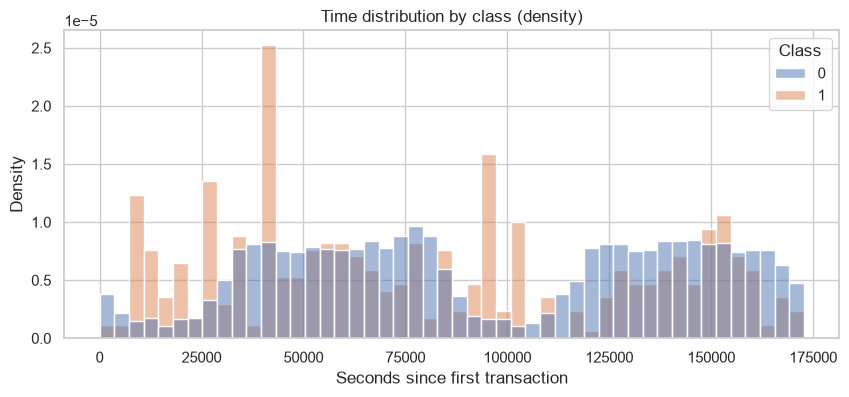

In [11]:
print(df.groupby("Class")["Time"].describe())

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="Time", hue="Class", bins=48, stat="density", common_norm=False)
plt.title("Time distribution by class (density)")
plt.xlabel("Seconds since first transaction")
plt.show()

### 4.4 V1–V28

V28    0.328
V27    0.396
V26    0.482
V25    0.521
V24    0.606
V23    0.624
V21    0.724
V22    0.725
V20    0.770
V19    0.813
V18    0.837
V17    0.843
V16    0.874
V15    0.915
V14    0.952
V12    0.995
V13    0.995
V11    1.019
V10    1.078
V8     1.179
V7     1.228
V6     1.332
V5     1.377
V4     1.414
V2     1.647
V1     1.948
V9     2.541
V3     8.087
dtype: float64


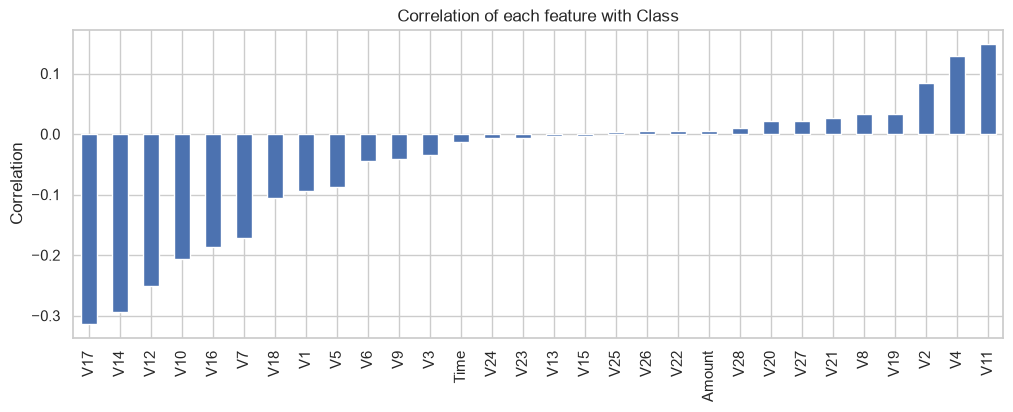

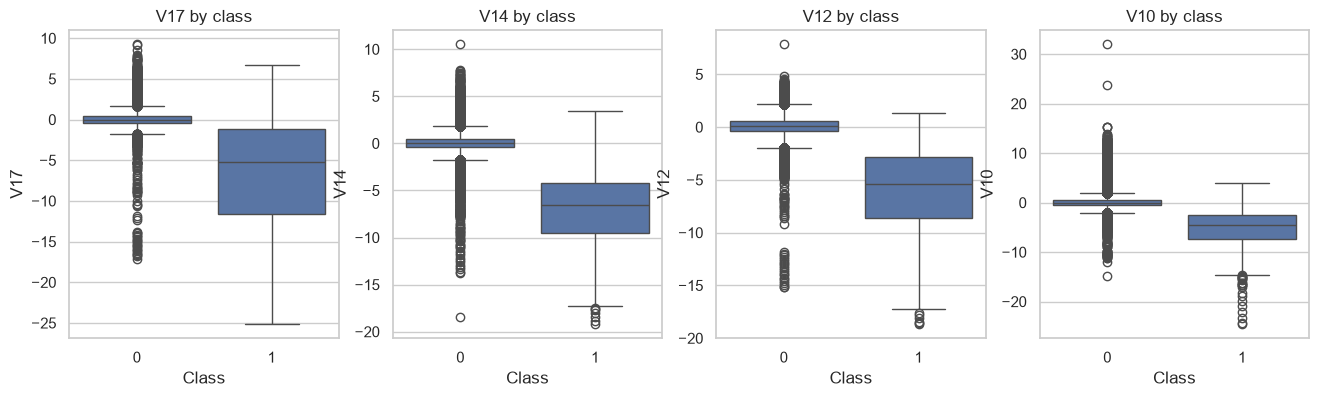

Largest correlation between two V features: 0.019
V2    0.533416
V7    0.400409
V5    0.387694
dtype: float64


In [12]:
v_columns = [f"V{i}" for i in range(1, 29)]
print(df[v_columns].std().round(3).sort_values())

corr_with_class = df[v_columns + ["Time", "Amount"]].corrwith(df["Class"]).sort_values()
plt.figure(figsize=(12, 4))
corr_with_class.plot(kind="bar")
plt.title("Correlation of each feature with Class")
plt.ylabel("Correlation")
plt.show()

top_features = corr_with_class.abs().sort_values(ascending=False).head(4).index
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, top_features):
    sns.boxplot(x="Class", y=col, data=df, ax=ax)
    ax.set_title(f"{col} by class")
plt.show()

v_corr = df[v_columns].corr().abs()
max_v_corr = v_corr.where(~np.eye(len(v_columns), dtype=bool)).max().max()
print("Largest correlation between two V features:", round(max_v_corr, 3))
print(df[v_columns].corrwith(df["Amount"]).abs().sort_values(ascending=False).head(3))

### 4.5 Unusual values audit

In [13]:
display(df[v_columns].describe().T[["min", "max"]])

whole_numbers = df[v_columns] == df[v_columns].round()
rows_with_whole_numbers = whole_numbers.any(axis=1)
print("Rows with exact whole-number V values:", rows_with_whole_numbers.sum())
print("Total exact whole-number V values:", whole_numbers.sum().sum())
print(df[rows_with_whole_numbers]["Class"].value_counts())
print(whole_numbers.sum()[whole_numbers.sum() > 0])

display(df[rows_with_whole_numbers])

,min,max
V1,-56.407510,2.454930
V2,-72.715728,22.057729
V3,-48.325589,4232.000000
V4,-5.683171,16.875344
V5,-113.743307,34.801666
V6,-26.160506,73.301626
V7,-43.557242,120.589494
V8,-73.216718,20.007208
V9,-13.434066,1221.000000
V10,-24.588262,32.000000


Rows with exact whole-number V values: 48
Total exact whole-number V values: 120
Class
0    48
Name: count, dtype: int64
V1     11
V2      4
V3      5
V4      6
V5     10
V6     22
V7      6
V8      1
V9     20
V10     6
V11     2
V12     7
V13     3
V14     2
V15    15
dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
28926,35294.0,1.117336,-0.010796,0.376815,1.299324,-0.289774,0.000000,-0.185222,0.259440,0.371473,0.109424,0.776415,0.022229,-2.462228,0.709771,-0.547441,-0.420255,0.140263,-0.205849,-0.062437,-0.319797,-0.075174,-0.129342,-0.049189,-0.022752,0.556874,-0.322732,0.021063,0.001286,9.99,0
28927,35294.0,1.187270,-0.426101,-0.596041,-0.579219,1.519092,0.000000,-0.996477,0.955938,0.354880,-0.064121,-0.102109,0.046783,0.196759,0.117484,1.590993,0.988328,-1.072790,0.451312,-0.015838,0.142097,-0.028782,-0.318996,-0.014490,1.030740,0.295195,0.401948,-0.012739,0.027819,52.14,0
28928,35295.0,1.213666,0.219618,0.301681,0.587957,-0.417497,0.000000,-0.097142,0.010750,-0.047909,-0.078845,1.428489,0.293853,-1.040819,0.144132,0.523362,0.731136,-0.189445,0.342037,0.100273,-0.146358,-0.249978,-0.814527,0.131206,0.256797,0.146519,0.081135,-0.034531,0.017992,1.29,0
28929,35295.0,0.039490,-0.715862,2.432075,-1.729158,-1.609506,0.000000,-0.645934,-0.127354,-1.470741,1.013711,-0.928952,-0.984815,0.476402,-1.310958,-0.429085,-0.658526,0.629036,0.178460,0.058298,-0.168162,-0.211270,0.079883,-0.054117,0.379427,-0.198717,-0.264513,-0.064949,-0.184302,29.90,0
28930,35295.0,1.236543,0.103187,0.369052,0.439345,-0.363048,0.000000,-0.122451,0.026545,-0.020925,0.136001,0.992525,0.347137,-0.841203,0.641262,0.479947,0.649498,-0.730076,0.200617,0.303068,-0.140196,-0.239535,-0.786722,0.094901,-0.038419,0.192859,0.101370,-0.041035,0.003349,3.57,0
28931,35296.0,-0.249867,0.040587,1.826757,-0.721078,-0.334278,0.000000,0.744453,-0.567971,-0.242874,1.165658,-1.052035,-1.438233,-1.130617,-0.686532,0.922794,-1.110874,-0.822192,1.229203,-2.097043,-0.606786,-0.482467,-0.534799,-0.040062,-0.554068,-0.627047,-0.766348,-0.733929,-0.632241,83.00,0
28933,35298.0,-1.306677,-0.309542,1.233300,0.402188,0.772385,0.000000,0.743774,0.298897,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.219473,-0.292316,-0.056146,-0.504692,0.228999,0.159061,0.077269,0.223589,-0.351194,0.164394,-0.493205,0.045546,0.131053,155.00,0
28934,35298.0,0.707941,-0.705610,1.069862,1.739592,-0.761644,0.995496,-0.364217,0.348000,0.000000,-0.346684,0.706337,2.032555,0.345117,-0.639828,0.000000,-0.958987,0.490466,-0.905398,0.405492,0.191464,-0.252894,-0.641667,-0.086982,0.039673,0.355570,-0.546851,0.059726,0.049546,181.11,0
28935,35298.0,-2.024706,-1.834811,1.450273,-2.349434,-0.858789,0.000000,-0.793409,1.124311,0.000000,0.229567,1.690780,-0.270820,-0.033866,0.153220,0.000000,-0.886084,1.314746,-0.830002,-2.235743,0.195673,0.412827,0.753433,0.436012,-1.072614,0.102747,-0.083269,-0.060505,-0.133255,252.00,0
28936,35299.0,1.085884,-0.195899,1.234210,1.434712,-0.922560,0.000000,-0.725266,0.319138,0.000000,-0.149817,-0.840452,-0.260057,-1.494676,-0.031932,0.000000,-0.100310,0.102172,-0.331927,-0.616762,-0.244417,-0.047264,0.003969,0.037679,0.042323,0.280796,-0.359675,0.075780,0.033487,19.00,0


### Step 4 findings
- **Class imbalance:** 283,253 non-fraud vs 473 fraud transactions, so accuracy cannot be the main metric and PR-AUC is used as the primary metric.
- **Amount:** strongly right-skewed (skewness ≈ 16.98). Fraud transactions have a lower median amount (9.82 vs 22.00). 1,808 transactions have `Amount = 0` (25 of them fraud). The log transform above is for visualisation only.
- **Time:** kept as a plain numeric feature. The distribution is shown for information only.
- **V1–V28:** the features are not on a common scale (standard deviation from 0.328 to 8.087), so scale-sensitive models need scaling. V17, V14, V12 and V10 show the strongest correlation with `Class`. The observed pairwise V–V correlations are very small (max 0.019), consistent with their PCA origin. These correlations are descriptive only and are not used for feature selection.
- **Unusual values:** the dataset contains several unusual PCA values, including extreme and exact-integer observations (48 rows, 120 values, all `Class = 0`, including `V3 = 4232` and `V9 = 1221`). Because `V1`–`V28` are anonymised, we cannot establish from the supplied information whether they are valid observations or data errors. No rows are removed or changed.

------

## Step 5 : Define features & target
**Objective:** Separate the cleaned data into input features `X` and target `y`, and fix the feature order (`Time`, `V1`–`V28`, `Amount`). This order is used for training and must stay the same wherever the model is used.

In [14]:
feature_columns = [col for col in expected_columns if col != "Class"]
X = df[feature_columns]
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature order correct:", list(X.columns) == feature_columns)
print("Class in X:", "Class" in X.columns)
print(y.value_counts())

X shape: (283726, 30)
y shape: (283726,)
Feature order correct: True
Class in X: False
Class
0    283253
1       473
Name: count, dtype: int64


---

## Step 6 : Stratified train / validation / test split
**Objective:** Split `X` and `y` into training (70%), validation (15%) and test (15%) sets, stratified on `Class` so each set keeps the same fraud rate. The test set is set aside and not used for training or model selection.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

for name, X_part, y_part in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    print(f"{name}: {X_part.shape}, frauds = {y_part.sum()}, fraud % = {round(y_part.mean() * 100, 5)}")

print("Train-validation overlap:", len(set(X_train.index) & set(X_val.index)))
print("Train-test overlap:", len(set(X_train.index) & set(X_test.index)))
print("Validation-test overlap:", len(set(X_val.index) & set(X_test.index)))
print("Total rows:", len(X_train) + len(X_val) + len(X_test))

Train: (198608, 30), frauds = 331, fraud % = 0.16666
Validation: (42559, 30), frauds = 71, fraud % = 0.16683
Test: (42559, 30), frauds = 71, fraud % = 0.16683
Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0
Total rows: 283726


### Step 6 insights
- The cleaned data was split into **198,608 training**, **42,559 validation** and **42,559 test** rows (70% / 15% / 15%), adding up to all 283,726 rows.
- Stratification kept the fraud rate almost identical in every set: **0.16666%** (train), **0.16683%** (validation) and **0.16683%** (test).
- Fraud cases are split as **331 / 71 / 71**. With only 71 frauds in validation and test, small differences between models on these sets may be due to chance, so CV results are reported as mean ± standard deviation.
- There is **no overlap** between the three sets, so no transaction is used for both training and evaluation.
- No scaling, resampling or model fitting has been done yet. Anything learned from data is fitted on the training data only, and the test set stays untouched.

----

## Step 7 : Build preprocessing & leakage-safe pipelines
**Objective:** Use RobustScaler for scale-sensitive models (Logistic Regression, KNN, Linear SVM, ANN), because one extreme `V3` value inflates its training standard deviation about 6.4 times, which would distort StandardScaler. Scaling is placed inside a pipeline so it is fitted only on training data, including within each CV fold. Tree-based models and Gaussian NB are left unscaled.

In [16]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

def build_pipeline(model, scale):
    if scale:
        return Pipeline([("scaler", RobustScaler()), ("model", model)])
    return Pipeline([("model", model)])

check_scaler = RobustScaler()
check_scaler.fit(X_train)

X_train_scaled = pd.DataFrame(check_scaler.transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(check_scaler.transform(X_val), columns=X_val.columns)

check_columns = ["Time", "V3", "V9", "Amount"]
for name, data in [("Train", X_train_scaled), ("Validation", X_val_scaled)]:
    median = data[check_columns].median().round(3)
    iqr = (data[check_columns].quantile(0.75) - data[check_columns].quantile(0.25)).round(3)
    print(f"{name} median:", median.to_dict())
    print(f"{name} IQR:   ", iqr.to_dict())

Train median: {'Time': 0.0, 'V3': 0.0, 'V9': 0.0, 'Amount': 0.0}
Train IQR:    {'Time': 1.0, 'V3': 1.0, 'V9': 1.0, 'Amount': 1.0}
Validation median: {'Time': -0.003, 'V3': 0.004, 'V9': -0.001, 'Amount': -0.013}
Validation IQR:    {'Time': 1.001, 'V3': 1.005, 'V9': 1.0, 'Amount': 0.983}


### Step 7 insights
- RobustScaler is used for scale-sensitive models because it relies on the median and IQR, which the extreme `V3` and `V9` values cannot distort. No rows are removed or clipped.
- The training data scales to exactly median 0 and IQR 1 for every checked feature (`Time`, `V3`, `V9`, `Amount`).
- The validation data scales to values close to, but not exactly, 0 and 1 (e.g. `Amount` median −0.013, IQR 0.983). This confirms it was transformed with values learned from the training data, not refitted on validation.
- `build_pipeline` keeps scaling inside each model's pipeline, so during 5-fold CV the scaler is refitted on each training fold only and never sees the held-out fold.
- `check_scaler` was used only for this check. Each model uses the scaler inside its own pipeline.

-----

## Step 8 : Define evaluation framework
**Objective:** Set up one shared way of evaluating models so every ML and DL model is judged on the same metrics, with PR-AUC as the primary metric. A baseline that always predicts non-fraud shows why accuracy is misleading on this data.

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, average_precision_score, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
}

def run_cv(name, pipeline):
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    return row

def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def evaluate_on_set(name, model, X, y, threshold=None):
    scores = get_scores(model, X)
    if threshold is None:
        y_pred = model.predict(X)
    else:
        y_pred = (scores >= threshold).astype(int)
    return {
        "model": name,
        "pr_auc": average_precision_score(y, scores),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, scores),
        "accuracy": accuracy_score(y, y_pred),
        "confusion_matrix": confusion_matrix(y, y_pred),
    }

dummy_pipeline = build_pipeline(DummyClassifier(strategy="most_frequent"), scale=False)

dummy_cv = run_cv("Dummy (always non-fraud)", dummy_pipeline)
display(pd.DataFrame([dummy_cv]).round(5))

dummy_pipeline.fit(X_train, y_train)
dummy_val = evaluate_on_set("Dummy (always non-fraud)", dummy_pipeline, X_val, y_val)
for key, value in dummy_val.items():
    print(key, ":", value)

,model,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
0,Dummy (always non-fraud),0.00167,0.00001,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.99833,0.00001


model : Dummy (always non-fraud)
pr_auc : 0.0016682722808336662
precision : 0.0
recall : 0.0
f1 : 0.0
roc_auc : 0.5
accuracy : 0.9983317277191663
confusion_matrix : [[42488     0]
 [   71     0]]


### Step 8 insights
- The dummy model that always predicts non-fraud reaches **99.83% accuracy while catching 0 frauds** (recall 0, confusion matrix shows all 71 validation frauds missed). This is why accuracy is reported for reference only.
- Its PR-AUC (**0.00167**) equals the fraud rate, which is the "no skill" level. Every real model must clearly beat this value.
- All models use the same 5 stratified folds (66–67 frauds per fold) and the same metrics, so their results are directly comparable. Results are reported as mean ± standard deviation across folds.
- Without a tuned threshold, each model uses its own `predict()` cut-off (0.5 for probability models, 0.0 for Linear SVM decision scores).
- The dummy row is a reference point only and is not one of the 8 benchmark models.

------

## Step 9 : ML stage 1 — untreated baseline benchmark
**Objective:** Run all 8 ML models with their standard settings and no imbalance handling, using 5-fold stratified CV on the training data only. This is the reference point for judging whether class weighting and resampling actually improve fraud detection.

In [18]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

baseline_models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    ("Decision Tree", DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    ("Random Forest", RandomForestClassifier(random_state=RANDOM_STATE), False),
    ("KNN", KNeighborsClassifier(), True),
    ("Linear SVM", LinearSVC(random_state=RANDOM_STATE), True),
    ("Gaussian NB", GaussianNB(), False),
    ("HistGradientBoosting", HistGradientBoostingClassifier(random_state=RANDOM_STATE), False),
    ("XGBoost", XGBClassifier(random_state=RANDOM_STATE, n_jobs=1), False),
]

stage1_results = []
for name, model, scale in baseline_models:
    start = time.time()
    row = run_cv(name, build_pipeline(model, scale))
    row["strategy"] = "baseline"
    row["time_sec"] = round(time.time() - start, 1)
    stage1_results.append(row)
    print(f"{name} done in {row['time_sec']} seconds")

stage1_df = pd.DataFrame(stage1_results)
display(stage1_df.sort_values("pr_auc_mean", ascending=False).round(4))

Logistic Regression done in 7.5 seconds
Decision Tree done in 22.8 seconds
Random Forest done in 200.0 seconds
KNN done in 142.3 seconds
Linear SVM done in 6.4 seconds
Gaussian NB done in 5.0 seconds
HistGradientBoosting done in 3.2 seconds
XGBoost done in 4.6 seconds


,model,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,strategy,time_sec
2,Random Forest,0.8363,0.0325,0.9379,0.0331,0.7644,0.0398,0.8416,0.0288,0.9410,0.0129,0.9995,0.0001,baseline,200.0
3,KNN,0.7706,0.0421,0.9148,0.0376,0.7313,0.0485,0.8116,0.0340,0.9138,0.0201,0.9994,0.0001,baseline,142.3
0,Logistic Regression,0.7582,0.0409,0.8699,0.0600,0.6223,0.0429,0.7238,0.0350,0.9764,0.0038,0.9992,0.0001,baseline,7.5
7,XGBoost,0.7580,0.0352,0.8773,0.0569,0.7705,0.0234,0.8193,0.0274,0.9584,0.0094,0.9994,0.0001,baseline,4.6
4,Linear SVM,0.7529,0.0524,0.8758,0.0598,0.6013,0.0547,0.7113,0.0464,0.9664,0.0047,0.9992,0.0001,baseline,6.4
6,HistGradientBoosting,0.6346,0.0615,0.4634,0.0668,0.7254,0.0617,0.5628,0.0565,0.8039,0.0419,0.9981,0.0003,baseline,3.2
1,Decision Tree,0.5933,0.0914,0.7556,0.0913,0.7826,0.0395,0.7666,0.0589,0.8911,0.0198,0.9992,0.0002,baseline,22.8
5,Gaussian NB,0.1766,0.0157,0.1456,0.0091,0.6406,0.0526,0.2370,0.0142,0.9679,0.0111,0.9931,0.0004,baseline,5.0


### Step 9 insights
- **Ranking by CV PR-AUC (mean ± std):** Random Forest 0.836 ± 0.033, KNN 0.771 ± 0.042, Logistic Regression 0.758 ± 0.041, XGBoost 0.758 ± 0.035, Linear SVM 0.753 ± 0.052, HistGradientBoosting 0.635 ± 0.062, Decision Tree 0.593 ± 0.091, Gaussian NB 0.177 ± 0.016.
- All 8 models are far above the dummy baseline (PR-AUC 0.00167), so every model learns real fraud signal even without imbalance handling.
- Accuracy is between 0.993 and 0.9995 for every model, so it cannot separate good models from weak ones.
- **Gaussian NB** has a high ROC-AUC (0.968) but a very low PR-AUC (0.177) and precision (0.146). This shows how ROC-AUC can look strong on imbalanced data while the model raises many false alarms.
- **Decision Tree** has the highest recall (0.783) but a low PR-AUC, because a single tree produces mostly hard 0/1 scores, which give a poor precision-recall curve.
- Logistic Regression, XGBoost and Linear SVM are within about 0.005 PR-AUC of each other. This difference is small relative to their fold-to-fold variability (std 0.035–0.052), so their ordering may not be robust.
- **HistGradientBoosting** with default settings has the lowest ROC-AUC of the boosting models (0.804) and varies a lot across folds. This is recorded as its baseline result; no settings are changed in this step.

----

## Step 10 : ML stage 1 — class-imbalance weighting
**Objective:** Rerun the models that support class weighting, with fraud cases given more weight during training, using the same 5-fold stratified CV on the training data. This tests whether weighting improves fraud detection compared with the Step 9 baseline, without changing the training data. `KNeighborsClassifier` and `GaussianNB` in scikit-learn do not provide a `class_weight` parameter, so they have no class-weighted version and are shown as N/A in the comparison table. Their Step 9 baseline results are used.

In [19]:
stage1_results = [row for row in stage1_results if row["strategy"] == "baseline"]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("XGBoost scale_pos_weight:", round(scale_pos_weight, 2))

weighted_models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE), True),
    ("Decision Tree", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE), False),
    ("Random Forest", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE), False),
    ("Linear SVM", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE), True),
    ("HistGradientBoosting", HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE), False),
    ("XGBoost", XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=1), False),
]

for name, model, scale in weighted_models:
    start = time.time()
    row = run_cv(name, build_pipeline(model, scale))
    row["strategy"] = "class_weighted"
    row["time_sec"] = round(time.time() - start, 1)
    stage1_results.append(row)
    print(f"{name} (class weighted) done in {row['time_sec']} seconds")

stage1_df = pd.DataFrame(stage1_results)

baseline = stage1_df[stage1_df["strategy"] == "baseline"].set_index("model")
weighted = stage1_df[stage1_df["strategy"] == "class_weighted"].set_index("model")

comparison = pd.DataFrame({
    "pr_auc_baseline": baseline["pr_auc_mean"],
    "pr_auc_weighted": weighted["pr_auc_mean"],
    "pr_auc_change": weighted["pr_auc_mean"] - baseline["pr_auc_mean"],
    "precision_baseline": baseline["precision_mean"],
    "precision_weighted": weighted["precision_mean"],
    "recall_baseline": baseline["recall_mean"],
    "recall_weighted": weighted["recall_mean"],
    "f1_baseline": baseline["f1_mean"],
    "f1_weighted": weighted["f1_mean"],
})
display(comparison.sort_values("pr_auc_weighted", ascending=False).round(4).fillna("N/A"))

XGBoost scale_pos_weight: 599.02
Logistic Regression (class weighted) done in 8.4 seconds
Decision Tree (class weighted) done in 10.0 seconds
Random Forest (class weighted) done in 68.1 seconds
Linear SVM (class weighted) done in 8.2 seconds
HistGradientBoosting (class weighted) done in 74.1 seconds
XGBoost (class weighted) done in 7.5 seconds


,pr_auc_baseline,pr_auc_weighted,pr_auc_change,precision_baseline,precision_weighted,recall_baseline,recall_weighted,f1_baseline,f1_weighted
model,,,,,,,,,
XGBoost,0.7580,0.8512,0.0931,0.8773,0.9164,0.7705,0.8218,0.8193,0.8663
Random Forest,0.8363,0.8313,-0.005,0.9379,0.9323,0.7644,0.7856,0.8416,0.8525
Logistic Regression,0.7582,0.7443,-0.014,0.8699,0.0555,0.6223,0.9125,0.7238,0.1046
HistGradientBoosting,0.6346,0.7442,0.1096,0.4634,0.4642,0.7254,0.84,0.5628,0.5943
Linear SVM,0.7529,0.7287,-0.0242,0.8758,0.0682,0.6013,0.9066,0.7113,0.1267
Decision Tree,0.5933,0.5444,-0.0489,0.7556,0.7387,0.7826,0.737,0.7666,0.7363
Gaussian NB,0.1766,N/A,N/A,0.1456,N/A,0.6406,N/A,0.2370,N/A
KNN,0.7706,N/A,N/A,0.9148,N/A,0.7313,N/A,0.8116,N/A


### Step 10 insights
- **XGBoost** with `scale_pos_weight` (599.02) shows the largest overall gain: CV PR-AUC rises from 0.758 to **0.851** (+0.093), with precision (0.916), recall (0.822) and F1 (0.866) all improving at the same time.
- **HistGradientBoosting** with balanced class weights improves from 0.635 to **0.744** (+0.110). Its ROC-AUC rises from 0.804 to 0.956 and its fold-to-fold variation decreases.
- **Random Forest** is essentially unchanged (0.836 → 0.831). The difference is small relative to its fold-to-fold variability (std about 0.038).
- **Logistic Regression** and **Linear SVM**: recall rises to about 0.91, but precision falls to 0.056 and 0.068 at the default cut-off, so F1 drops to 0.105 and 0.127. Their PR-AUC changes only slightly (−0.014 and −0.024), which shows that weighting mainly shifts their default decision cut-off rather than improving how well they rank fraud cases.
- **Decision Tree** gets worse with weighting (0.593 → 0.544).
- **KNN** and **Gaussian NB** are shown as N/A because their scikit-learn implementations have no `class_weight` parameter. For Gaussian NB, changing the class priors would only rescale its fraud scores without changing their order, so PR-AUC would stay the same. Both models keep their Step 9 baseline results.
- Across all 14 Stage 1 results, the highest CV PR-AUC values are class-weighted XGBoost (0.851), baseline Random Forest (0.836) and class-weighted Random Forest (0.831).

-----

## Step 11 : Stage 1 ML comparison
**Objective:** Compare all 14 Stage 1 results (8 baseline and 6 class-weighted from Steps 9 and 10) using mean 5-fold CV PR-AUC, and select the 3 strongest ML model families. Each family is represented by its best strategy, and families are ranked by mean CV PR-AUC. Fold standard deviations are shown as context for how much each result varies across folds.

,model,strategy,pr_auc_mean,pr_auc_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,roc_auc_std
0,XGBoost,class_weighted,0.8512,0.0351,0.9164,0.8218,0.8663,0.9795,0.0087
1,Random Forest,baseline,0.8363,0.0325,0.9379,0.7644,0.8416,0.9410,0.0129
2,Random Forest,class_weighted,0.8313,0.0379,0.9323,0.7856,0.8525,0.9537,0.0190
3,KNN,baseline,0.7706,0.0421,0.9148,0.7313,0.8116,0.9138,0.0201
4,Logistic Regression,baseline,0.7582,0.0409,0.8699,0.6223,0.7238,0.9764,0.0038
5,XGBoost,baseline,0.7580,0.0352,0.8773,0.7705,0.8193,0.9584,0.0094
6,Linear SVM,baseline,0.7529,0.0524,0.8758,0.6013,0.7113,0.9664,0.0047
7,Logistic Regression,class_weighted,0.7443,0.0506,0.0555,0.9125,0.1046,0.9816,0.0093
8,HistGradientBoosting,class_weighted,0.7442,0.0442,0.4642,0.8400,0.5943,0.9564,0.0149
9,Linear SVM,class_weighted,0.7287,0.0422,0.0682,0.9066,0.1267,0.9820,0.0091


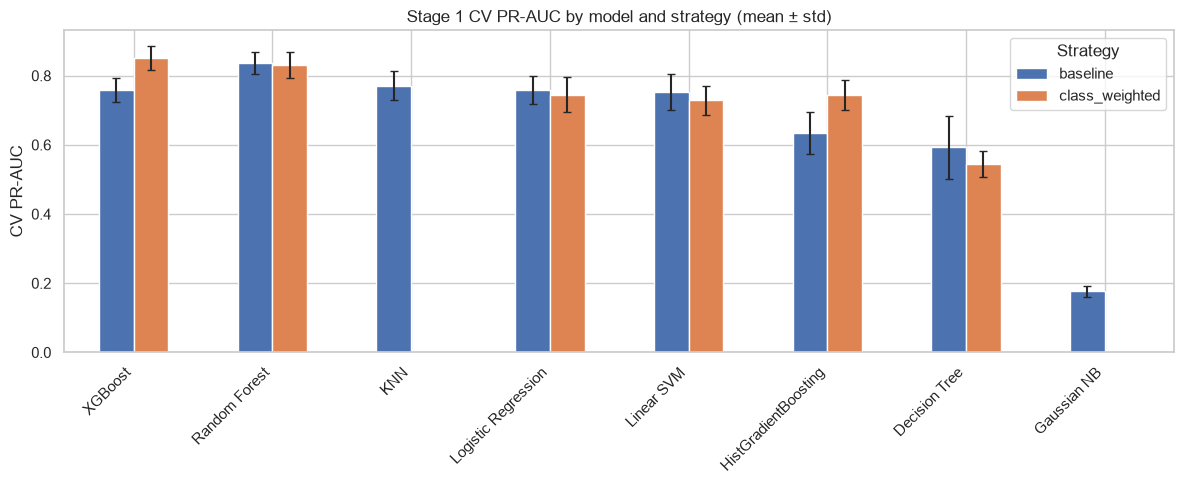

,model,strategy,pr_auc_mean,pr_auc_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,roc_auc_std
1,XGBoost,class_weighted,0.8512,0.0351,0.9164,0.8218,0.8663,0.9795,0.0087
2,Random Forest,baseline,0.8363,0.0325,0.9379,0.7644,0.8416,0.9410,0.0129
3,KNN,baseline,0.7706,0.0421,0.9148,0.7313,0.8116,0.9138,0.0201
4,Logistic Regression,baseline,0.7582,0.0409,0.8699,0.6223,0.7238,0.9764,0.0038
5,Linear SVM,baseline,0.7529,0.0524,0.8758,0.6013,0.7113,0.9664,0.0047
6,HistGradientBoosting,class_weighted,0.7442,0.0442,0.4642,0.8400,0.5943,0.9564,0.0149
7,Decision Tree,baseline,0.5933,0.0914,0.7556,0.7826,0.7666,0.8911,0.0198
8,Gaussian NB,baseline,0.1766,0.0157,0.1456,0.6406,0.2370,0.9679,0.0111


Selected top 3 ML families: ['XGBoost', 'Random Forest', 'KNN']
3rd: KNN (baseline) PR-AUC 0.7706 ± 0.0421
4th: Logistic Regression (baseline) PR-AUC 0.7582 ± 0.0409
Difference in mean PR-AUC: 0.0124


In [20]:
summary_columns = ["model", "strategy", "pr_auc_mean", "pr_auc_std", "precision_mean", "recall_mean", "f1_mean", "roc_auc_mean", "roc_auc_std"]
stage1_table = stage1_df[summary_columns].sort_values("pr_auc_mean", ascending=False).reset_index(drop=True)
display(stage1_table.round(4))

pr_auc_means = stage1_df.pivot(index="model", columns="strategy", values="pr_auc_mean")
pr_auc_stds = stage1_df.pivot(index="model", columns="strategy", values="pr_auc_std")
model_order = pr_auc_means.max(axis=1).sort_values(ascending=False).index

pr_auc_means.loc[model_order].plot(kind="bar", yerr=pr_auc_stds.loc[model_order], capsize=3, figsize=(12, 5))
plt.title("Stage 1 CV PR-AUC by model and strategy (mean ± std)")
plt.ylabel("CV PR-AUC")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()

best_per_model = stage1_table.drop_duplicates("model").reset_index(drop=True)
best_per_model.index = best_per_model.index + 1
display(best_per_model.round(4))

top3_models = best_per_model.head(3)[["model", "strategy"]].reset_index(drop=True)
print("Selected top 3 ML families:", list(top3_models["model"]))

third = best_per_model.loc[3]
fourth = best_per_model.loc[4]
print(f"3rd: {third['model']} ({third['strategy']}) PR-AUC {third['pr_auc_mean']:.4f} ± {third['pr_auc_std']:.4f}")
print(f"4th: {fourth['model']} ({fourth['strategy']}) PR-AUC {fourth['pr_auc_mean']:.4f} ± {fourth['pr_auc_std']:.4f}")
print(f"Difference in mean PR-AUC: {third['pr_auc_mean'] - fourth['pr_auc_mean']:.4f}")

### Step 11 insights
- Families are ranked by their best mean CV PR-AUC. The selected top 3 are **XGBoost** (class-weighted, 0.851 ± 0.035), **Random Forest** (baseline, 0.836 ± 0.033) and **KNN** (baseline, 0.771 ± 0.042).
- KNN is ahead of Logistic Regression (baseline, 0.758 ± 0.041) by 0.012 in mean PR-AUC. This difference is small relative to their fold-to-fold variability, so the 3rd/4th ordering may not be robust. KNN is selected based on its higher mean PR-AUC.
- The best strategy differs by family: class weighting improves XGBoost, while Random Forest is strongest at baseline and KNN has only a baseline result because its scikit-learn implementation has no `class_weight` parameter.
- The remaining families rank as Logistic Regression (0.758), Linear SVM (0.753), HistGradientBoosting (0.744, class-weighted), Decision Tree (0.593) and Gaussian NB (0.177).

----

## Step 12 : ML stage 2 — sampling experiments
**Objective:** For the 3 families selected in Step 11 (XGBoost, Random Forest, KNN), test random undersampling and SMOTE oversampling and compare them with their baseline and class-weighted results from Steps 9 and 10. Resampling is applied only inside each training fold, so every validation fold keeps the real fraud rate. RobustScaler is applied before SMOTE for all three models because SMOTE creates synthetic fraud cases from nearest neighbours, and without scaling the distances would be dominated by `Time` and `Amount`. Models in the sampling runs use no class weights because the sampler already balances the classes 1:1.

Sampling runs cover the selected top 3: True
XGBoost (undersampling) done in 7.2 seconds
Random Forest (undersampling) done in 4.8 seconds
KNN (undersampling) done in 4.9 seconds
XGBoost (smote) done in 10.9 seconds
Random Forest (smote) done in 334.5 seconds
KNN (smote) done in 235.6 seconds


,model,strategy,pr_auc_mean,pr_auc_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,roc_auc_std
0,XGBoost,smote,0.8528,0.0321,0.7774,0.8309,0.8030,0.9813,0.0078
1,XGBoost,class_weighted,0.8512,0.0351,0.9164,0.8218,0.8663,0.9795,0.0087
2,Random Forest,smote,0.8492,0.0346,0.8904,0.8249,0.8561,0.9738,0.0108
3,Random Forest,baseline,0.8363,0.0325,0.9379,0.7644,0.8416,0.9410,0.0129
4,Random Forest,class_weighted,0.8313,0.0379,0.9323,0.7856,0.8525,0.9537,0.0190
5,KNN,baseline,0.7706,0.0421,0.9148,0.7313,0.8116,0.9138,0.0201
6,XGBoost,baseline,0.7580,0.0352,0.8773,0.7705,0.8193,0.9584,0.0094
7,Random Forest,undersampling,0.7269,0.0513,0.0596,0.9066,0.1116,0.9817,0.0055
8,XGBoost,undersampling,0.6971,0.0518,0.0375,0.9217,0.0721,0.9800,0.0036
9,KNN,smote,0.5278,0.0329,0.3782,0.8310,0.5191,0.9209,0.0183


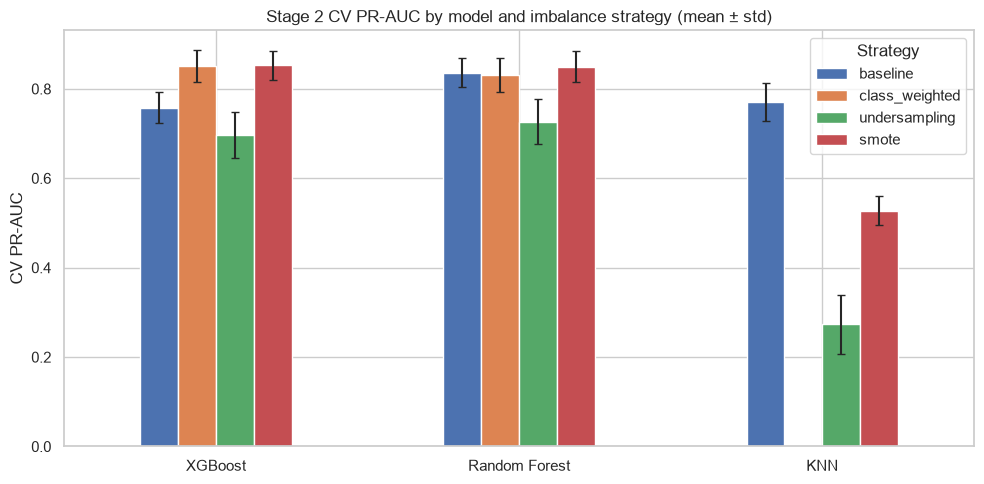

,model,strategy,pr_auc_mean,pr_auc_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,roc_auc_std
0,XGBoost,smote,0.8528,0.0321,0.7774,0.8309,0.8030,0.9813,0.0078
1,Random Forest,smote,0.8492,0.0346,0.8904,0.8249,0.8561,0.9738,0.0108
2,KNN,baseline,0.7706,0.0421,0.9148,0.7313,0.8116,0.9138,0.0201


In [21]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

def build_sampling_pipeline(model, sampler, scale):
    steps = []
    if scale:
        steps.append(("scaler", RobustScaler()))
    steps.append(("sampler", sampler))
    steps.append(("model", model))
    return ImbPipeline(steps)

top3_names = list(top3_models["model"])

sampling_runs = [
    ("XGBoost", "undersampling", XGBClassifier(random_state=RANDOM_STATE, n_jobs=1), RandomUnderSampler(random_state=RANDOM_STATE), False),
    ("Random Forest", "undersampling", RandomForestClassifier(random_state=RANDOM_STATE), RandomUnderSampler(random_state=RANDOM_STATE), False),
    ("KNN", "undersampling", KNeighborsClassifier(), RandomUnderSampler(random_state=RANDOM_STATE), True),
    ("XGBoost", "smote", XGBClassifier(random_state=RANDOM_STATE, n_jobs=1), SMOTE(random_state=RANDOM_STATE), True),
    ("Random Forest", "smote", RandomForestClassifier(random_state=RANDOM_STATE), SMOTE(random_state=RANDOM_STATE), True),
    ("KNN", "smote", KNeighborsClassifier(), SMOTE(random_state=RANDOM_STATE), True),
]
print("Sampling runs cover the selected top 3:", set(run[0] for run in sampling_runs) == set(top3_names))

stage2_results = []
for name, strategy, model, sampler, scale in sampling_runs:
    start = time.time()
    row = run_cv(name, build_sampling_pipeline(model, sampler, scale))
    row["strategy"] = strategy
    row["time_sec"] = round(time.time() - start, 1)
    stage2_results.append(row)
    print(f"{name} ({strategy}) done in {row['time_sec']} seconds")

stage2_df = pd.concat([stage1_df[stage1_df["model"].isin(top3_names)], pd.DataFrame(stage2_results)], ignore_index=True)
stage2_table = stage2_df[summary_columns].sort_values("pr_auc_mean", ascending=False).reset_index(drop=True)
display(stage2_table.round(4))

strategy_order = ["baseline", "class_weighted", "undersampling", "smote"]
stage2_means = stage2_df.pivot(index="model", columns="strategy", values="pr_auc_mean").loc[top3_names, strategy_order]
stage2_stds = stage2_df.pivot(index="model", columns="strategy", values="pr_auc_std").loc[top3_names, strategy_order]

stage2_means.plot(kind="bar", yerr=stage2_stds, capsize=3, figsize=(10, 5))
plt.title("Stage 2 CV PR-AUC by model and imbalance strategy (mean ± std)")
plt.ylabel("CV PR-AUC")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()

stage2_best = stage2_table.drop_duplicates("model").reset_index(drop=True)
display(stage2_best.round(4))

### Step 12 insights
- **Selected configuration per family (highest mean CV PR-AUC):** XGBoost with SMOTE (0.853 ± 0.032), Random Forest with SMOTE (0.849 ± 0.035) and KNN at baseline (0.771 ± 0.042).
- **XGBoost:** SMOTE (0.853) and class weighting (0.851) give almost the same mean PR-AUC; the 0.002 difference is small relative to fold-to-fold variability. At the default cut-off, SMOTE gives lower precision (0.777 vs 0.916) and lower F1 (0.803 vs 0.866) than class weighting.
- **Random Forest:** SMOTE improves mean PR-AUC from 0.836 (baseline) to 0.849, with recall rising from 0.764 to 0.825 and precision falling from 0.938 to 0.890. One 5-fold run takes about 5.5 minutes with SMOTE.
- **KNN:** under SMOTE, precision fell from 0.915 to 0.378 and PR-AUC dropped to 0.528, indicating that this resampling strategy is a poor fit for KNN on this dataset. Undersampling lowers its PR-AUC further, to 0.273.
- **Undersampling** gives the lowest PR-AUC for all three families. Each training fold keeps only about 530 rows (265 per class), so most of the non-fraud information is discarded. Recall rises to 0.88–0.92, but precision falls to 0.04–0.06.

## Step 13 : ML hyperparameter tuning
**Objective:** Tune the 3 configurations selected in Step 12 (KNN at baseline, XGBoost with SMOTE, Random Forest with SMOTE) using the same 5-fold stratified CV on the training data, with average precision (PR-AUC) as the tuning metric. The full pipeline, including scaling and SMOTE, is refitted inside every fold. KNN uses a full grid search (10 combinations); XGBoost (20 of 432 combinations) and Random Forest (8 of 54 combinations) use randomised search because a full grid would be too slow. The SMOTE ratio (`sampling_strategy`) is tuned for both SMOTE pipelines.

### 13.1 KNN — grid search

In [22]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

tuning_results = []

def summarise_search(name, configuration, search, start):
    best = search.best_index_
    untuned = stage2_best.loc[stage2_best["model"] == name, "pr_auc_mean"].iloc[0]
    tuned_mean = search.cv_results_["mean_test_score"][best]
    tuned_std = search.cv_results_["std_test_score"][best]
    print(f"{name} best parameters: {search.best_params_}")
    print(f"{name} tuned CV PR-AUC: {tuned_mean:.4f} ± {tuned_std:.4f} (untuned: {untuned:.4f})")
    print(f"{name} search time: {round(time.time() - start, 1)} seconds")
    return {
        "model": name,
        "configuration": configuration,
        "untuned_pr_auc": untuned,
        "tuned_pr_auc_mean": tuned_mean,
        "tuned_pr_auc_std": tuned_std,
        "change": tuned_mean - untuned,
        "best_params": search.best_params_,
    }

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 11, 15],
    "model__weights": ["uniform", "distance"],
}

start = time.time()
knn_search = GridSearchCV(build_pipeline(KNeighborsClassifier(), scale=True), knn_grid, scoring="average_precision", cv=cv, n_jobs=-1)
knn_search.fit(X_train, y_train)
tuning_results.append(summarise_search("KNN", "baseline", knn_search, start))

KNN best parameters: {'model__n_neighbors': 15, 'model__weights': 'distance'}
KNN tuned CV PR-AUC: 0.7974 ± 0.0394 (untuned: 0.7706)
KNN search time: 1193.7 seconds


### 13.2 XGBoost with SMOTE — randomised search

In [23]:
xgb_space = {
    "sampler__sampling_strategy": [0.1, 0.5, 1.0],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.05, 0.1, 0.2, 0.3],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}
xgb_pipeline = build_sampling_pipeline(XGBClassifier(random_state=RANDOM_STATE, n_jobs=1), SMOTE(random_state=RANDOM_STATE), scale=True)

start = time.time()
xgb_search = RandomizedSearchCV(xgb_pipeline, xgb_space, n_iter=20, scoring="average_precision", cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
xgb_search.fit(X_train, y_train)
tuning_results.append(summarise_search("XGBoost", "smote", xgb_search, start))

XGBoost best parameters: {'sampler__sampling_strategy': 0.1, 'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}
XGBoost tuned CV PR-AUC: 0.8596 ± 0.0304 (untuned: 0.8528)
XGBoost search time: 183.0 seconds


### 13.3 Random Forest with SMOTE — randomised search

In [24]:
rf_space = {
    "sampler__sampling_strategy": [0.1, 0.5, 1.0],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5],
}
rf_pipeline = build_sampling_pipeline(RandomForestClassifier(random_state=RANDOM_STATE), SMOTE(random_state=RANDOM_STATE), scale=True)

start = time.time()
rf_search = RandomizedSearchCV(rf_pipeline, rf_space, n_iter=8, scoring="average_precision", cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
rf_search.fit(X_train, y_train)
tuning_results.append(summarise_search("Random Forest", "smote", rf_search, start))

Random Forest best parameters: {'sampler__sampling_strategy': 0.1, 'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_depth': 20}
Random Forest tuned CV PR-AUC: 0.8543 ± 0.0321 (untuned: 0.8492)
Random Forest search time: 3105.5 seconds


### 13.4 Tuning summary

In [25]:
tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.round(4))

,model,configuration,untuned_pr_auc,tuned_pr_auc_mean,tuned_pr_auc_std,change,best_params
0,KNN,baseline,0.7706,0.7974,0.0394,0.0268,"{'model__n_neighbors': 15, 'model__weights': '..."
1,XGBoost,smote,0.8528,0.8596,0.0304,0.0068,"{'sampler__sampling_strategy': 0.1, 'model__su..."
2,Random Forest,smote,0.8492,0.8543,0.0321,0.0051,"{'sampler__sampling_strategy': 0.1, 'model__n_..."


### Step 13 insights
- All three tuned configurations improve on their untuned Step 12 results: XGBoost with SMOTE 0.853 → **0.860**, Random Forest with SMOTE 0.849 → **0.854**, and KNN 0.771 → **0.797**. The tuned versions are therefore kept for all three families.
- The improvements for XGBoost (+0.007) and Random Forest (+0.005) are small relative to their fold-to-fold variability (std about 0.03). KNN shows the largest gain (+0.027).
- Within the configurations sampled during tuning, a SMOTE ratio of 0.1 produced the best CV PR-AUC for both XGBoost and Random Forest. With this ratio, synthetic fraud cases are added until frauds make up 10% of the non-fraud count, rather than balancing the classes 1:1.
- KNN's best setting (k = 15, distance weighting) is at the upper end of the searched `n_neighbors` range (3–15), so a larger k was not tested.
- Search times were about 20 minutes (KNN), 3 minutes (XGBoost) and 52 minutes (Random Forest). Random Forest with SMOTE is the most computationally expensive configuration.

----

## Step 14 : Select best ML finalist
**Objective:** Evaluate the three tuned ML configurations from Step 13 on the validation set for the first time and select one best ML model by validation PR-AUC. For each family, the tuned configuration is kept only if its CV PR-AUC is at least as high as the untuned configuration from Step 12. The tuned pipelines were already refitted on the full training data in Step 13, so no model is retrained here. The test set is not used.

,model,untuned_cv_pr_auc,tuned_cv_pr_auc,kept
0,KNN,0.7706,0.7974,tuned
1,XGBoost,0.8528,0.8596,tuned
2,Random Forest,0.8492,0.8543,tuned


KNN evaluated in 32.7 seconds
XGBoost evaluated in 0.5 seconds
Random Forest evaluated in 1.0 seconds


,model,pr_auc,precision,recall,f1,roc_auc,accuracy,cv_pr_auc
0,Random Forest,0.8441,0.9032,0.7887,0.8421,0.9788,0.9995,0.8543
1,XGBoost,0.8202,0.8889,0.7887,0.8358,0.9736,0.9995,0.8596
2,KNN,0.7463,0.9796,0.6761,0.8000,0.8869,0.9994,0.7974


Random Forest confusion matrix [[TN, FP], [FN, TP]]: [[42482, 6], [15, 56]]
XGBoost confusion matrix [[TN, FP], [FN, TP]]: [[42481, 7], [15, 56]]
KNN confusion matrix [[TN, FP], [FN, TP]]: [[42487, 1], [23, 48]]


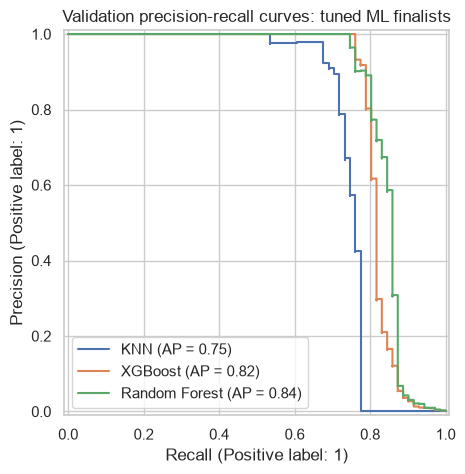

Best ML finalist (highest validation PR-AUC): Random Forest


In [26]:
from sklearn.metrics import PrecisionRecallDisplay

searches = {"XGBoost": xgb_search, "Random Forest": rf_search, "KNN": knn_search}

selection_rows = []
ml_finalists = {}
for row in tuning_results:
    name = row["model"]
    if row["tuned_pr_auc_mean"] >= row["untuned_pr_auc"]:
        kept = "tuned"
        ml_finalists[name] = searches[name].best_estimator_
    else:
        kept = "untuned"
        print(f"{name}: untuned configuration has higher CV PR-AUC and must be refitted before validation")
    selection_rows.append({
        "model": name,
        "untuned_cv_pr_auc": row["untuned_pr_auc"],
        "tuned_cv_pr_auc": row["tuned_pr_auc_mean"],
        "kept": kept,
    })
display(pd.DataFrame(selection_rows).round(4))

cv_pr_auc = tuning_df.set_index("model")["tuned_pr_auc_mean"]

validation_results = []
for name, model in ml_finalists.items():
    start = time.time()
    result = evaluate_on_set(name, model, X_val, y_val)
    result["cv_pr_auc"] = cv_pr_auc[name]
    validation_results.append(result)
    print(f"{name} evaluated in {round(time.time() - start, 1)} seconds")

validation_df = pd.DataFrame(validation_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
display(validation_df.drop(columns="confusion_matrix").round(4))

for _, row in validation_df.iterrows():
    print(f"{row['model']} confusion matrix [[TN, FP], [FN, TP]]: {row['confusion_matrix'].tolist()}")

fig, ax = plt.subplots(figsize=(7, 5))
for name, model in ml_finalists.items():
    PrecisionRecallDisplay.from_predictions(y_val, get_scores(model, X_val), name=name, ax=ax)
ax.set_title("Validation precision-recall curves: tuned ML finalists")
plt.show()

best_ml_name = validation_df.loc[0, "model"]
best_ml_model = ml_finalists[best_ml_name]
print("Best ML finalist (highest validation PR-AUC):", best_ml_name)

### Step 14 insights
- All three families keep their tuned configurations, since each tuned CV PR-AUC is higher than the untuned one (KNN 0.797 vs 0.771, XGBoost 0.860 vs 0.853, Random Forest 0.854 vs 0.849).
- On the validation set, **Random Forest with SMOTE** has the highest PR-AUC (**0.844**), followed by XGBoost with SMOTE (0.820) and KNN (0.746). **Random Forest is selected as the best ML finalist.**
- The order of Random Forest and XGBoost differs between CV (XGBoost 0.860 vs Random Forest 0.854) and validation (Random Forest 0.844 vs XGBoost 0.820). With only 71 fraud cases in the validation set, a small number of cases can change this order.
- At the default cut-off, Random Forest and XGBoost both detect **56 of the 71** validation frauds (recall 0.789). Random Forest raises 6 false alarms and XGBoost raises 7.
- KNN has the highest precision (0.980, 1 false alarm) but the lowest recall (0.676, 23 frauds missed), and its precision-recall curve falls off at lower recall than the other two.

----

## Step 15 : Build baseline ANN
**Objective:** Build a baseline artificial neural network (ANN) for the same fraud classification task and evaluate it on the validation set with the same metrics used for the ML models. The baseline uses the original class distribution (no class weighting). Inputs are scaled with RobustScaler fitted on the training data only, as in Step 7. The network has two hidden layers (32 and 16 units, ReLU) and a sigmoid output that gives a fraud probability. Training uses the Adam optimiser (learning rate 0.001), binary cross-entropy loss and a batch size of 2048, for up to 100 epochs with early stopping on validation PR-AUC (patience 5, best weights restored). The random seed is reset immediately before model creation to improve reproducibility; repeated runs in the current environment produced identical results. Because the validation set is used for early stopping, the ANN's validation scores are slightly optimistic compared with the ML models, which did not use validation data during training.

Epochs run: 54
Best epoch (highest validation PR-AUC): 49
Training time: 20.9 seconds


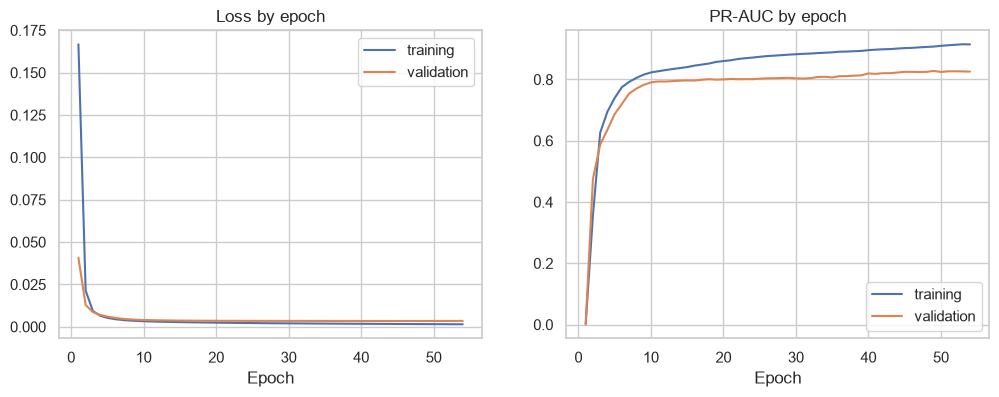

,model,pr_auc,precision,recall,f1,roc_auc,accuracy
0,Baseline ANN,0.8288,0.9455,0.7324,0.8254,0.9589,0.9995
1,Random Forest,0.8441,0.9032,0.7887,0.8421,0.9788,0.9995


Baseline ANN confusion matrix [[TN, FP], [FN, TP]]: [[42485, 3], [19, 52]]
Random Forest confusion matrix [[TN, FP], [FN, TP]]: [[42482, 6], [15, 56]]


In [29]:
ann_scaler = RobustScaler()
X_train_ann = ann_scaler.fit_transform(X_train)
X_val_ann = ann_scaler.transform(X_val)

def evaluate_scores(name, y, scores, threshold=0.5):
    y_pred = (scores >= threshold).astype(int)
    return {
        "model": name,
        "pr_auc": average_precision_score(y, scores),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, scores),
        "accuracy": accuracy_score(y, y_pred),
        "confusion_matrix": confusion_matrix(y, y_pred),
    }

tf.keras.utils.set_random_seed(RANDOM_STATE)
baseline_ann = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train_ann.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
baseline_ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")],
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True)

start = time.time()
history = baseline_ann.fit(
    X_train_ann, y_train,
    validation_data=(X_val_ann, y_val),
    epochs=100,
    batch_size=2048,
    callbacks=[early_stop],
    verbose=0,
)
print(f"Epochs run: {len(history.history['loss'])}")
print(f"Best epoch (highest validation PR-AUC): {np.argmax(history.history['val_pr_auc']) + 1}")
print(f"Training time: {round(time.time() - start, 1)} seconds")

epochs = range(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history.history["loss"], label="training")
axes[0].plot(epochs, history.history["val_loss"], label="validation")
axes[0].set_title("Loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(epochs, history.history["pr_auc"], label="training")
axes[1].plot(epochs, history.history["val_pr_auc"], label="validation")
axes[1].set_title("PR-AUC by epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.show()

ann_val_scores = baseline_ann.predict(X_val_ann, verbose=0).ravel()
baseline_ann_val = evaluate_scores("Baseline ANN", y_val, ann_val_scores)

best_ml_val = validation_df.loc[0].drop("cv_pr_auc").to_dict()
ann_vs_ml = pd.DataFrame([baseline_ann_val, best_ml_val])
display(ann_vs_ml.drop(columns="confusion_matrix").round(4))
for _, row in ann_vs_ml.iterrows():
    print(f"{row['model']} confusion matrix [[TN, FP], [FN, TP]]: {row['confusion_matrix'].tolist()}")

### Step 15 insights
- The baseline ANN trained for 54 epochs in about 21 seconds. Early stopping restored the weights from epoch 49, which had the highest validation PR-AUC.
- On the validation set, the baseline ANN reaches a PR-AUC of **0.829**, with precision 0.946, recall 0.732 and F1 0.825. It detects **52 of the 71** validation frauds with **3 false alarms**.
- Compared with the best ML finalist from Step 14 (Random Forest with SMOTE, PR-AUC 0.844), the baseline ANN has a slightly lower PR-AUC and recall (0.732 vs 0.789) but higher precision (0.946 vs 0.903) and fewer false alarms (3 vs 6).
- Validation PR-AUC rises quickly to about 0.80 within the first 10 epochs and then improves slowly to about 0.83, while training PR-AUC continues to about 0.92. The widening gap shows the network fitting the training data more closely than it generalises in later epochs.
- Because the validation set was used for early stopping, these validation scores are slightly optimistic compared with the ML models, which did not use validation data during training.

----

## Step 16 : ANN imbalance handling
**Objective:** Train the same ANN architecture as Step 15 with balanced class weights, so errors on fraud cases count more in the training loss, and compare it with the unweighted baseline ANN on the validation set. The weights are calculated from the training labels with the same formula as scikit-learn's `class_weight="balanced"` used in Step 10: total rows divided by (2 × rows in that class). All other settings (architecture, optimiser, batch size, epoch limit and early stopping on validation PR-AUC) are the same as Step 15. The strategy with the higher validation PR-AUC is kept.

Class weights: {0: 0.5008, 1: 300.0121}
Epochs run: 15
Best epoch (highest validation PR-AUC): 10
Training time: 7.7 seconds


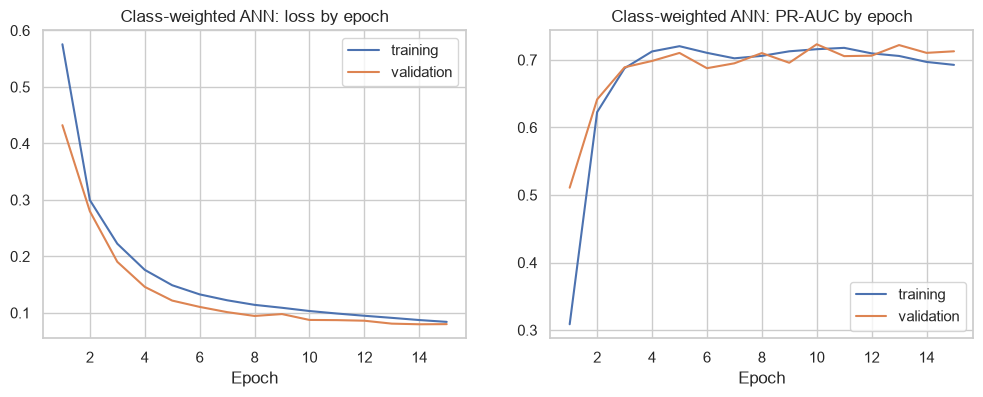

,model,pr_auc,precision,recall,f1,roc_auc,accuracy
0,Baseline ANN,0.8288,0.9455,0.7324,0.8254,0.9589,0.9995
1,Class-weighted ANN,0.6818,0.0541,0.8732,0.1019,0.9614,0.9743


Baseline ANN confusion matrix [[TN, FP], [FN, TP]]: [[42485, 3], [19, 52]]
Class-weighted ANN confusion matrix [[TN, FP], [FN, TP]]: [[41404, 1084], [9, 62]]
ANN strategy kept (highest validation PR-AUC): baseline


In [30]:
n_train = len(y_train)
n_non_fraud = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
class_weights = {0: n_train / (2 * n_non_fraud), 1: n_train / (2 * n_fraud)}
print("Class weights:", {label: round(weight, 4) for label, weight in class_weights.items()})

def build_ann():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(X_train_ann.shape[1],)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")],
    )
    return model

tf.keras.utils.set_random_seed(RANDOM_STATE)
weighted_ann = build_ann()
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True)

start = time.time()
weighted_history = weighted_ann.fit(
    X_train_ann, y_train,
    validation_data=(X_val_ann, y_val),
    epochs=100,
    batch_size=2048,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0,
)
print(f"Epochs run: {len(weighted_history.history['loss'])}")
print(f"Best epoch (highest validation PR-AUC): {np.argmax(weighted_history.history['val_pr_auc']) + 1}")
print(f"Training time: {round(time.time() - start, 1)} seconds")

epochs = range(1, len(weighted_history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, weighted_history.history["loss"], label="training")
axes[0].plot(epochs, weighted_history.history["val_loss"], label="validation")
axes[0].set_title("Class-weighted ANN: loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(epochs, weighted_history.history["pr_auc"], label="training")
axes[1].plot(epochs, weighted_history.history["val_pr_auc"], label="validation")
axes[1].set_title("Class-weighted ANN: PR-AUC by epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.show()

weighted_ann_val_scores = weighted_ann.predict(X_val_ann, verbose=0).ravel()
weighted_ann_val = evaluate_scores("Class-weighted ANN", y_val, weighted_ann_val_scores)

ann_strategy_df = pd.DataFrame([baseline_ann_val, weighted_ann_val])
display(ann_strategy_df.drop(columns="confusion_matrix").round(4))
for _, row in ann_strategy_df.iterrows():
    print(f"{row['model']} confusion matrix [[TN, FP], [FN, TP]]: {row['confusion_matrix'].tolist()}")

if weighted_ann_val["pr_auc"] > baseline_ann_val["pr_auc"]:
    best_ann_strategy = "class_weighted"
else:
    best_ann_strategy = "baseline"
print("ANN strategy kept (highest validation PR-AUC):", best_ann_strategy)

### Step 16 insights
- Balanced class weights from the training labels are {0: 0.5008, 1: 300.01}, so each fraud case counts about 600 times as much as a non-fraud case in the training loss.
- With class weighting, validation PR-AUC falls from **0.829** (baseline ANN) to **0.682**, while ROC-AUC is almost unchanged (0.961 vs 0.959).
- At the 0.5 cut-off, recall rises from 0.732 to 0.873 (62 vs 52 of the 71 validation frauds detected), but false alarms rise from 3 to **1,084**, so precision falls to 0.054, F1 to 0.102 and accuracy to 0.974.
- With class weighting, early stopping ended training after 15 epochs (best epoch 10), compared with 54 epochs (best epoch 49) for the baseline, which shows that validation PR-AUC stopped improving sooner under this weighting.
- The PR-AUC values in the training curves are calculated by Keras during training and differ slightly from scikit-learn's average precision shown in the results table, because the two use different approximations of the precision-recall curve.
- The **baseline (unweighted) ANN is kept**, because it has the higher validation PR-AUC. This is the same pattern seen for Logistic Regression and Linear SVM with class weighting in Step 10, where recall rose but precision and PR-AUC fell.

-----

## Step 17 : ANN hyperparameter tuning
**Objective:** Tune the ANN on the validation set and keep the configuration with the highest validation PR-AUC. The search covers the hidden layer sizes, dropout, learning rate, batch size and a fraud class weight. The fraud weights tested (1 = no weighting, 5 and 25) are milder than the balanced weight of about 300 used in Step 16, which lowered validation PR-AUC. The Step 15 baseline configuration is always included as a candidate, and 20 further unique configurations are sampled at random from the 96 possible combinations. Each candidate uses the same training settings as Step 15 (seed reset before model creation, up to 100 epochs, early stopping on validation PR-AUC with patience 5 and best weights restored). Because the validation set is used both for early stopping and for choosing the configuration, the selected ANN's validation score is optimistic.

Number of candidates: 21
All candidates unique: True
Candidate 0: validation PR-AUC 0.8288 (22.2 seconds)
Candidate 1: validation PR-AUC 0.7298 (13.1 seconds)
Candidate 2: validation PR-AUC 0.8236 (32.3 seconds)
Candidate 3: validation PR-AUC 0.7247 (20.4 seconds)
Candidate 4: validation PR-AUC 0.6989 (10.0 seconds)
Candidate 5: validation PR-AUC 0.7290 (19.3 seconds)
Candidate 6: validation PR-AUC 0.8318 (39.1 seconds)
Candidate 7: validation PR-AUC 0.8202 (28.6 seconds)
Candidate 8: validation PR-AUC 0.7277 (12.4 seconds)
Candidate 9: validation PR-AUC 0.8249 (25.8 seconds)
Candidate 10: validation PR-AUC 0.8161 (19.3 seconds)
Candidate 11: validation PR-AUC 0.7287 (12.3 seconds)
Candidate 12: validation PR-AUC 0.8238 (21.0 seconds)
Candidate 13: validation PR-AUC 0.8261 (17.4 seconds)
Candidate 14: validation PR-AUC 0.8201 (12.8 seconds)
Candidate 15: validation PR-AUC 0.8305 (29.8 seconds)
Candidate 16: validation PR-AUC 0.8380 (22.6 seconds)
Candidate 17: validation PR-AUC 0.8267 

,model,pr_auc,precision,recall,f1,roc_auc,accuracy,hidden_units,dropout,learning_rate,batch_size,fraud_weight,epochs,time_sec
16,Candidate 16,0.8380,0.9630,0.7324,0.8320,0.9637,0.9995,"(32, 16)",0.2,0.0010,1024,1.0,33,22.6
6,Candidate 6,0.8318,0.9623,0.7183,0.8226,0.9605,0.9995,"(64, 32, 16)",0.2,0.0005,2048,1.0,59,39.1
15,Candidate 15,0.8305,0.9153,0.7606,0.8308,0.9600,0.9995,"(64, 32, 16)",0.2,0.0005,1024,1.0,35,29.8
20,Candidate 20,0.8299,0.8636,0.8028,0.8321,0.9546,0.9995,"(64, 32)",0.2,0.0005,2048,5.0,58,34.7
0,Candidate 0,0.8288,0.9455,0.7324,0.8254,0.9589,0.9995,"(32, 16)",0.0,0.0010,2048,1.0,54,22.2
17,Candidate 17,0.8267,0.8358,0.7887,0.8116,0.9548,0.9994,"(64, 32)",0.0,0.0010,1024,5.0,19,15.0
13,Candidate 13,0.8261,0.6304,0.8169,0.7117,0.9580,0.9989,"(32, 16)",0.0,0.0010,1024,25.0,29,17.4
9,Candidate 9,0.8249,0.8814,0.7324,0.8000,0.9579,0.9994,"(16, 8)",0.0,0.0010,1024,1.0,47,25.8
12,Candidate 12,0.8238,0.8871,0.7746,0.8271,0.9640,0.9995,"(64, 32, 16)",0.2,0.0010,1024,1.0,23,21.0
2,Candidate 2,0.8236,0.9630,0.7324,0.8320,0.9574,0.9995,"(64, 32)",0.2,0.0005,2048,1.0,57,32.3


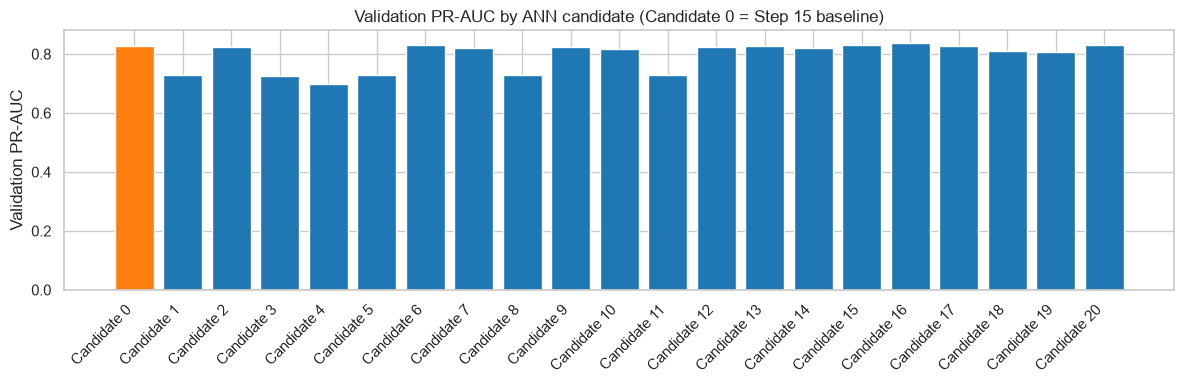

Best ANN candidate: Candidate 16
Best ANN parameters: {'learning_rate': 0.001, 'hidden_units': (32, 16), 'fraud_weight': 1.0, 'dropout': 0.2, 'batch_size': 1024}
Best ANN validation PR-AUC: 0.8380 (Step 15 baseline: 0.8288)
Best ANN confusion matrix [[TN, FP], [FN, TP]]: [[42486, 2], [19, 52]]


In [31]:
from sklearn.model_selection import ParameterSampler

def build_ann(hidden_units=(32, 16), dropout=0.0, learning_rate=0.001):
    layers = [tf.keras.Input(shape=(X_train_ann.shape[1],))]
    for units in hidden_units:
        layers.append(tf.keras.layers.Dense(units, activation="relu"))
        if dropout > 0:
            layers.append(tf.keras.layers.Dropout(dropout))
    layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))
    model = tf.keras.Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")],
    )
    return model

ann_space = {
    "hidden_units": [(16, 8), (32, 16), (64, 32), (64, 32, 16)],
    "dropout": [0.0, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [1024, 2048],
    "fraud_weight": [1.0, 5.0, 25.0],
}
baseline_params = {"hidden_units": (32, 16), "dropout": 0.0, "learning_rate": 0.001, "batch_size": 2048, "fraud_weight": 1.0}

sampled_params = ParameterSampler(ann_space, n_iter=21, random_state=RANDOM_STATE)
ann_candidates = [baseline_params] + [params for params in sampled_params if params != baseline_params][:20]
print("Number of candidates:", len(ann_candidates))
print("All candidates unique:", len({str(sorted(params.items())) for params in ann_candidates}) == len(ann_candidates))

ann_results = []
ann_models = []
search_start = time.time()
for i, params in enumerate(ann_candidates):
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = build_ann(params["hidden_units"], params["dropout"], params["learning_rate"])
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True)
    start = time.time()
    history = model.fit(
        X_train_ann, y_train,
        validation_data=(X_val_ann, y_val),
        epochs=100,
        batch_size=params["batch_size"],
        class_weight={0: 1.0, 1: params["fraud_weight"]},
        callbacks=[early_stop],
        verbose=0,
    )
    scores = model.predict(X_val_ann, verbose=0).ravel()
    result = evaluate_scores(f"Candidate {i}", y_val, scores)
    result.update(params)
    result["epochs"] = len(history.history["loss"])
    result["time_sec"] = round(time.time() - start, 1)
    ann_results.append(result)
    ann_models.append(model)
    print(f"Candidate {i}: validation PR-AUC {result['pr_auc']:.4f} ({result['time_sec']} seconds)")
print(f"Total search time: {round(time.time() - search_start, 1)} seconds")

ann_tuning_df = pd.DataFrame(ann_results)
display(ann_tuning_df.drop(columns="confusion_matrix").sort_values("pr_auc", ascending=False).round(4))

colors = ["tab:orange" if i == 0 else "tab:blue" for i in range(len(ann_tuning_df))]
plt.figure(figsize=(12, 4))
plt.bar(ann_tuning_df["model"], ann_tuning_df["pr_auc"], color=colors)
plt.title("Validation PR-AUC by ANN candidate (Candidate 0 = Step 15 baseline)")
plt.ylabel("Validation PR-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

best_index = ann_tuning_df["pr_auc"].idxmax()
best_ann_model = ann_models[best_index]
best_ann_params = ann_candidates[best_index]
best_ann_val = ann_results[best_index]
print("Best ANN candidate:", best_ann_val["model"])
print("Best ANN parameters:", best_ann_params)
print(f"Best ANN validation PR-AUC: {best_ann_val['pr_auc']:.4f} (Step 15 baseline: {ann_results[0]['pr_auc']:.4f})")
print(f"Best ANN confusion matrix [[TN, FP], [FN, TP]]: {best_ann_val['confusion_matrix'].tolist()}")

### Step 17 insights
- The search trained and evaluated 21 ANN candidates in about 7.3 minutes.
- The best candidate (**Candidate 16**: hidden layers 32 and 16, dropout 0.2, learning rate 0.001, batch size 1024, no class weighting) reaches a validation PR-AUC of **0.838**, compared with 0.829 for the Step 15 baseline (+0.009). It detects 52 of the 71 validation frauds with **2 false alarms** (precision 0.963, recall 0.732).
- The four best non-baseline candidates all use dropout 0.2, and three of them use no class weighting.
- Milder fraud weights did not improve on the best unweighted candidate: the best candidate with weight 5 reached 0.830 and the best with weight 25 reached 0.826. Candidates with weight 25 had precision between 0.57 and 0.69. **No class weighting is kept.**
- The smallest network (hidden layers 16 and 8) scored about 0.72–0.73 in four of its five candidates.
- The gain over the baseline is small, and the validation set (71 frauds) was used both for early stopping and for choosing the configuration, so the best candidate's validation score is optimistic.
- The best ANN's validation PR-AUC (0.838) is slightly below that of the best ML finalist from Step 14 (Random Forest with SMOTE, 0.844).

-----

## Step 18 : Select best DL finalist
**Objective:** Confirm and freeze one best deep-learning model from the ANN experiments in Steps 15–17, selected by validation PR-AUC. The stored model is checked to reproduce its validation score, its training and validation PR-AUC are compared to measure the generalisation gap, and its validation precision-recall curve is compared with the best ML finalist from Step 14. No model is retrained and the test set is not used. The ANN requires inputs scaled with the RobustScaler fitted in Step 15 (`ann_scaler`).

,model,pr_auc,precision,recall,f1,roc_auc,accuracy
0,Baseline ANN (Step 15),0.8288,0.9455,0.7324,0.8254,0.9589,0.9995
1,Class-weighted ANN (Step 16),0.6818,0.0541,0.8732,0.1019,0.9614,0.9743
2,ANN (Step 17 Candidate 16),0.8380,0.9630,0.7324,0.8320,0.9637,0.9995


Baseline ANN (Step 15) confusion matrix [[TN, FP], [FN, TP]]: [[42485, 3], [19, 52]]
Class-weighted ANN (Step 16) confusion matrix [[TN, FP], [FN, TP]]: [[41404, 1084], [9, 62]]
ANN (Step 17 Candidate 16) confusion matrix [[TN, FP], [FN, TP]]: [[42486, 2], [19, 52]]
Best DL finalist (highest validation PR-AUC): ANN (Step 17 Candidate 16)
Reproducibility check: recomputed validation PR-AUC 0.8380, stored 0.8380, match: True
Training PR-AUC: 0.8931
Validation PR-AUC: 0.8380
Gap (training - validation): 0.0551


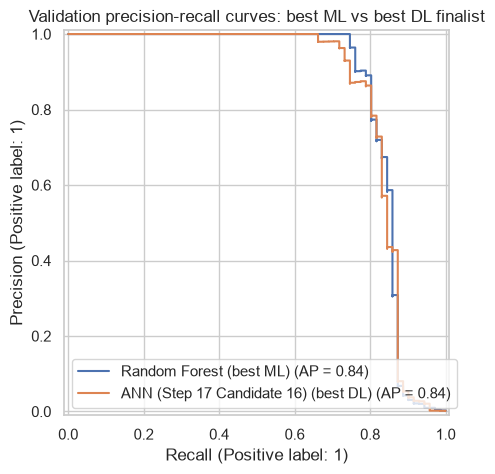

In [32]:
ann_summary = pd.DataFrame([
    {**baseline_ann_val, "model": "Baseline ANN (Step 15)"},
    {**weighted_ann_val, "model": "Class-weighted ANN (Step 16)"},
    {**best_ann_val, "model": f"ANN (Step 17 {best_ann_val['model']})"},
])
dl_models = [baseline_ann, weighted_ann, best_ann_model]
summary_cols = ["model", "pr_auc", "precision", "recall", "f1", "roc_auc", "accuracy"]
display(ann_summary[summary_cols].round(4))
for _, row in ann_summary.iterrows():
    print(f"{row['model']} confusion matrix [[TN, FP], [FN, TP]]: {row['confusion_matrix'].tolist()}")

best_dl_index = ann_summary["pr_auc"].idxmax()
best_dl_name = ann_summary.loc[best_dl_index, "model"]
best_dl_model = dl_models[best_dl_index]
best_dl_val_pr_auc = ann_summary.loc[best_dl_index, "pr_auc"]
print("Best DL finalist (highest validation PR-AUC):", best_dl_name)

dl_val_scores = best_dl_model.predict(X_val_ann, verbose=0).ravel()
check_pr_auc = average_precision_score(y_val, dl_val_scores)
print(f"Reproducibility check: recomputed validation PR-AUC {check_pr_auc:.4f}, stored {best_dl_val_pr_auc:.4f}, match: {np.isclose(check_pr_auc, best_dl_val_pr_auc)}")

dl_train_scores = best_dl_model.predict(X_train_ann, verbose=0).ravel()
dl_train_pr_auc = average_precision_score(y_train, dl_train_scores)
print(f"Training PR-AUC: {dl_train_pr_auc:.4f}")
print(f"Validation PR-AUC: {check_pr_auc:.4f}")
print(f"Gap (training - validation): {dl_train_pr_auc - check_pr_auc:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_val, get_scores(best_ml_model, X_val), name=f"{best_ml_name} (best ML)", ax=ax)
PrecisionRecallDisplay.from_predictions(y_val, dl_val_scores, name=f"{best_dl_name} (best DL)", ax=ax)
ax.set_title("Validation precision-recall curves: best ML vs best DL finalist")
plt.show()

### Step 18 insights
- Among the ANN experiments, the tuned ANN from Step 17 (Candidate 16) has the highest validation PR-AUC (**0.838**), ahead of the baseline ANN (0.829) and the class-weighted ANN (0.682). **It is selected as the best DL finalist.**
- Re-predicting with the stored model gives the same validation PR-AUC (0.8380), confirming that the selected model is unchanged since Step 17.
- The best ANN has a training PR-AUC of 0.893 and a validation PR-AUC of 0.838, a gap of 0.055. This indicates higher performance on the training data, although the gap is descriptive because the validation set was also used for early stopping and ANN model selection.
- On the validation set, the precision-recall curves of the best ML finalist (Random Forest with SMOTE) and the best DL finalist are very close, with average precision of about 0.84 for both. Random Forest keeps a precision of 1.0 up to a slightly higher recall (about 0.75 vs about 0.66).

----

## Step 19 : Validation threshold tuning
**Objective:** For the best ML finalist (Random Forest with SMOTE, Step 14) and the best DL finalist (ANN, Step 18), choose the decision threshold that maximises F1 on the validation set instead of assuming 0.5. F1 is used because no cost ratio between missed frauds and false alarms is available; it balances precision and recall without assigning an explicit business cost to either error type. If several thresholds give the same maximum F1, the lowest of them is chosen, which keeps recall at least as high. The selected thresholds are then frozen. Because the thresholds are chosen on the validation set (71 frauds), the validation F1 at the selected threshold is optimistic. The test set is not used.

,model,threshold_type,threshold,precision,recall,f1,confusion_matrix
0,Random Forest,default 0.5,0.5000,0.9032,0.7887,0.8421,"[[42482, 6], [15, 56]]"
1,Random Forest,tuned (max F1),0.7549,1.0000,0.7465,0.8548,"[[42488, 0], [18, 53]]"
2,ANN (Step 17 Candidate 16),default 0.5,0.5000,0.9630,0.7324,0.8320,"[[42486, 2], [19, 52]]"
3,ANN (Step 17 Candidate 16),tuned (max F1),0.3364,0.8636,0.8028,0.8321,"[[42479, 9], [14, 57]]"


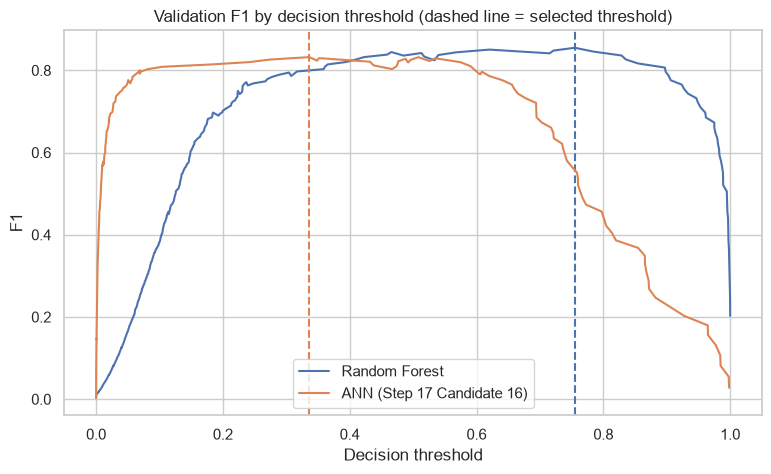

Frozen threshold for Random Forest: 0.7549
Frozen threshold for ANN (Step 17 Candidate 16): 0.3364


In [33]:
from sklearn.metrics import precision_recall_curve

def find_best_f1_threshold(y, scores):
    precision, recall, thresholds = precision_recall_curve(y, scores)
    precision = precision[:-1]
    recall = recall[:-1]
    denominator = precision + recall
    f1 = 2 * precision * recall / np.where(denominator == 0, 1, denominator)
    best = np.argmax(f1)
    return thresholds[best], thresholds, f1

ml_val_scores = get_scores(best_ml_model, X_val)
finalist_scores = {best_ml_name: ml_val_scores, best_dl_name: dl_val_scores}

threshold_rows = []
f1_curves = {}
tuned_thresholds = {}
for name, scores in finalist_scores.items():
    best_threshold, thresholds, f1 = find_best_f1_threshold(y_val, scores)
    f1_curves[name] = (thresholds, f1)
    tuned_thresholds[name] = best_threshold
    for label, threshold in [("default 0.5", 0.5), ("tuned (max F1)", best_threshold)]:
        result = evaluate_scores(name, y_val, scores, threshold)
        threshold_rows.append({
            "model": name,
            "threshold_type": label,
            "threshold": threshold,
            "precision": result["precision"],
            "recall": result["recall"],
            "f1": result["f1"],
            "confusion_matrix": result["confusion_matrix"].tolist(),
        })
display(pd.DataFrame(threshold_rows).round(4))

fig, ax = plt.subplots(figsize=(9, 5))
for name, (thresholds, f1) in f1_curves.items():
    line, = ax.plot(thresholds, f1, label=name)
    ax.axvline(tuned_thresholds[name], linestyle="--", color=line.get_color())
ax.set_title("Validation F1 by decision threshold (dashed line = selected threshold)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1")
ax.legend()
plt.show()

ml_threshold = tuned_thresholds[best_ml_name]
dl_threshold = tuned_thresholds[best_dl_name]
print(f"Frozen threshold for {best_ml_name}: {ml_threshold:.4f}")
print(f"Frozen threshold for {best_dl_name}: {dl_threshold:.4f}")

### Step 19 insights
- **Random Forest:** the F1-maximising threshold is **0.7549**, higher than the default 0.5. On the validation set, it removes all 6 false alarms (precision 1.000) but detects 3 fewer frauds (53 vs 56 of 71; recall 0.747 vs 0.789). F1 rises from 0.842 to **0.855**.
- **ANN:** the F1-maximising threshold is **0.3364**, lower than the default 0.5. It detects 5 more frauds (57 vs 52 of 71; recall 0.803 vs 0.732) at the cost of 7 more false alarms (9 vs 2). F1 is almost unchanged (0.8320 → 0.8321), so for the ANN the default and tuned thresholds perform almost equally well by F1.
- The two models move in opposite directions: the selected threshold makes Random Forest more conservative (fewer alerts) and the ANN more sensitive (more alerts).
- Both models have a wide range of thresholds with similar F1 (about 0.80–0.85), so F1 is not very sensitive to the exact threshold within that range.
- Maximising F1 balances precision and recall without assigning an explicit business cost to false negatives versus false positives. For Random Forest, this means accepting 3 more missed frauds in exchange for removing 6 false alarms on the validation set.
- The thresholds were chosen on the validation set (71 frauds), so the F1 values at the selected thresholds are optimistic. Both thresholds are now frozen.

## Step 20 : Freeze finalists before testing
**Objective:** Record the complete configuration of both finalists in one place before the test set is used: model, input scaling, imbalance strategy, hyperparameters, decision threshold and validation scores. Each frozen model is re-scored on the validation set to confirm that its PR-AUC and its confusion matrix at the frozen threshold are unchanged since Steps 14, 18 and 19. The ANN is re-scored from the raw validation features through `ann_scaler`, the same route new data will take. The test set has only been created (Step 6) and has not been used for any fitting, tuning or evaluation.

In [34]:
tuned_rows = {row["model"]: row for row in threshold_rows if row["threshold_type"] == "tuned (max F1)"}

frozen_finalists = {
    best_ml_name: {
        "family": "ML",
        "model": best_ml_model,
        "input_scaling": "RobustScaler inside the pipeline",
        "imbalance_strategy": f"SMOTE (sampling_strategy={searches[best_ml_name].best_params_['sampler__sampling_strategy']})",
        "hyperparameters": searches[best_ml_name].best_params_,
        "threshold": ml_threshold,
        "validation_pr_auc": validation_df.loc[0, "pr_auc"],
        "validation_f1_at_threshold": tuned_rows[best_ml_name]["f1"],
    },
    best_dl_name: {
        "family": "DL",
        "model": best_dl_model,
        "input_scaling": "RobustScaler fitted in Step 15 (ann_scaler)",
        "imbalance_strategy": f"none (fraud class weight {best_ann_params['fraud_weight']})",
        "hyperparameters": best_ann_params,
        "threshold": dl_threshold,
        "validation_pr_auc": best_dl_val_pr_auc,
        "validation_f1_at_threshold": tuned_rows[best_dl_name]["f1"],
    },
}

for name, finalist in frozen_finalists.items():
    if finalist["family"] == "ML":
        scores = get_scores(finalist["model"], X_val)
    else:
        scores = finalist["model"].predict(ann_scaler.transform(X_val), verbose=0).ravel()
    check = evaluate_scores(name, y_val, scores, finalist["threshold"])
    pr_auc_match = np.isclose(check["pr_auc"], finalist["validation_pr_auc"])
    matrix_match = check["confusion_matrix"].tolist() == tuned_rows[name]["confusion_matrix"]
    print(f"{name}: validation PR-AUC {check['pr_auc']:.4f} (match: {pr_auc_match}), confusion matrix at frozen threshold {check['confusion_matrix'].tolist()} (match: {matrix_match})")

print("Test set feature order correct:", list(X_test.columns) == feature_columns)
print(f"Test set: {X_test.shape[0]} rows, {y_test.sum()} frauds (not yet used for fitting, tuning or evaluation)")

frozen_summary = pd.DataFrame([
    {
        "model": name,
        "family": finalist["family"],
        "input_scaling": finalist["input_scaling"],
        "imbalance_strategy": finalist["imbalance_strategy"],
        "threshold": round(finalist["threshold"], 4),
        "validation_pr_auc": round(finalist["validation_pr_auc"], 4),
        "validation_f1_at_threshold": round(finalist["validation_f1_at_threshold"], 4),
    }
    for name, finalist in frozen_finalists.items()
])
display(frozen_summary)
for name, finalist in frozen_finalists.items():
    print(f"{name} hyperparameters: {finalist['hyperparameters']}")

Random Forest: validation PR-AUC 0.8441 (match: True), confusion matrix at frozen threshold [[42488, 0], [18, 53]] (match: True)
ANN (Step 17 Candidate 16): validation PR-AUC 0.8380 (match: True), confusion matrix at frozen threshold [[42479, 9], [14, 57]] (match: True)
Test set feature order correct: True
Test set: 42559 rows, 71 frauds (not yet used for fitting, tuning or evaluation)


,model,family,input_scaling,imbalance_strategy,threshold,validation_pr_auc,validation_f1_at_threshold
0,Random Forest,ML,RobustScaler inside the pipeline,SMOTE (sampling_strategy=0.1),0.7549,0.8441,0.8548
1,ANN (Step 17 Candidate 16),DL,RobustScaler fitted in Step 15 (ann_scaler),none (fraud class weight 1.0),0.3364,0.8380,0.8321


Random Forest hyperparameters: {'sampler__sampling_strategy': 0.1, 'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_depth': 20}
ANN (Step 17 Candidate 16) hyperparameters: {'learning_rate': 0.001, 'hidden_units': (32, 16), 'fraud_weight': 1.0, 'dropout': 0.2, 'batch_size': 1024}


### Step 20 insights
- Both finalists are frozen with their complete configuration:
  - **Random Forest (best ML):** RobustScaler and SMOTE (ratio 0.1) inside the pipeline, 100 trees, maximum depth 20, minimum leaf size 5, decision threshold **0.7549**.
  - **ANN (best DL):** inputs scaled with `ann_scaler`, hidden layers 32 and 16, dropout 0.2, learning rate 0.001, batch size 1024, no class weighting, decision threshold **0.3364**.
- Re-scoring each frozen model on the validation set reproduces its validation PR-AUC (Random Forest 0.8441, ANN 0.8380) and its confusion matrix at the frozen threshold exactly, confirming that neither model has changed since it was selected.
- The ANN check was run from the raw validation features through `ann_scaler`, confirming that the frozen scaler and model together give the same results as in Steps 18 and 19.
- On the validation set, at their frozen thresholds, Random Forest has an F1 of 0.855 and the ANN 0.832. These validation figures are optimistic because the validation set was used for model selection and threshold tuning.
- The test set (42,559 rows, 71 frauds) has the same feature order as the training data and has not been used for any fitting, tuning or evaluation.

----

## Step 21 : One-time final test evaluation
**Objective:** Evaluate the two finalists frozen in Step 20, Random Forest with SMOTE (best ML) and the tuned ANN (best DL), once on the test set (42,559 rows, 71 frauds), each at its frozen decision threshold. Each finalist is scored through its frozen route: Random Forest applies its own pipeline scaler, and the ANN's inputs are scaled with `ann_scaler`. PR-AUC (threshold-independent) is the primary metric; precision, recall, F1, accuracy and the confusion matrix are reported at the frozen thresholds, and ROC-AUC as a secondary metric. No model, hyperparameter or threshold is changed based on these results.

,model,family,threshold,pr_auc,precision,recall,f1,roc_auc,accuracy
0,Random Forest,ML,0.7549,0.8100,0.9444,0.7183,0.8160,0.9745,0.9995
1,ANN (Step 17 Candidate 16),DL,0.3364,0.8149,0.8209,0.7746,0.7971,0.9669,0.9993


Random Forest test confusion matrix [[TN, FP], [FN, TP]]: [[42485, 3], [20, 51]]
ANN (Step 17 Candidate 16) test confusion matrix [[TN, FP], [FN, TP]]: [[42476, 12], [16, 55]]


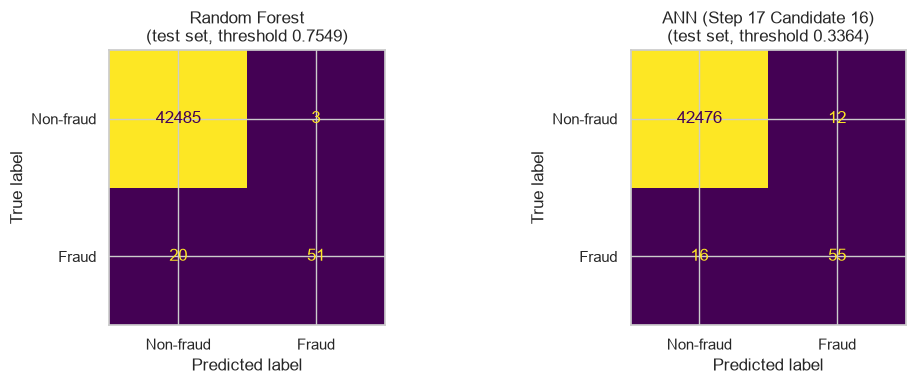

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

test_scores = {}
test_results = []
for name, finalist in frozen_finalists.items():
    if finalist["family"] == "ML":
        scores = get_scores(finalist["model"], X_test)
    else:
        scores = finalist["model"].predict(ann_scaler.transform(X_test), verbose=0).ravel()
    test_scores[name] = scores
    result = evaluate_scores(name, y_test, scores, finalist["threshold"])
    result["family"] = finalist["family"]
    result["threshold"] = finalist["threshold"]
    test_results.append(result)

test_results_df = pd.DataFrame(test_results)
test_columns = ["model", "family", "threshold", "pr_auc", "precision", "recall", "f1", "roc_auc", "accuracy"]
display(test_results_df[test_columns].round(4))
for _, row in test_results_df.iterrows():
    print(f"{row['model']} test confusion matrix [[TN, FP], [FN, TP]]: {row['confusion_matrix'].tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (_, row) in zip(axes, test_results_df.iterrows()):
    ConfusionMatrixDisplay(row["confusion_matrix"], display_labels=["Non-fraud", "Fraud"]).plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"{row['model']}\n(test set, threshold {row['threshold']:.4f})")
plt.tight_layout()
plt.show()

### Step 21 insights
- On the test set, the ANN has a slightly higher PR-AUC (**0.815**) than Random Forest (**0.810**), a difference of 0.005 on the primary metric.
- At their frozen thresholds, Random Forest detects **51 of the 71** test frauds (recall 0.718) with **3 false alarms** (precision 0.944, F1 0.816). The ANN detects **55 of 71** (recall 0.775) with **12 false alarms** (precision 0.821, F1 0.797).
- The metrics do not all favour the same model: the ANN is ahead on PR-AUC and recall, while Random Forest is ahead on precision, F1 and ROC-AUC (0.975 vs 0.967).
- Both finalists score lower on the test set than on the validation set (PR-AUC: Random Forest 0.844 → 0.810, ANN 0.838 → 0.815), consistent with the validation results being optimistic after model selection and threshold tuning on that set.
- With only 71 fraud cases in the test set, the PR-AUC difference of 0.005 and the difference of 4 detected frauds should be interpreted cautiously; the test set is too small to claim that this performance gap is robust.
- Accuracy is about 0.999 for both models and does not distinguish between them.

----

## Step 22 : ML vs DL final comparison
**Objective:** Compare the ML and DL models in two clearly separated views. Chart 1 is a descriptive development overview: ML families show their best 5-fold CV PR-AUC (tuned value where tuning was done) and the ANN variants show their validation PR-AUC. Because these come from different procedures, Chart 1 is not used to decide between ML and DL. Chart 2 is the authoritative comparison: the two frozen finalists on the same test set, showing PR-AUC, precision, recall and F1 (2a) and their test precision-recall curves with each frozen threshold marked (2b). The finalist with the higher test PR-AUC is selected as the final deployment model under the predefined primary-metric rule. The conclusion is limited to this test set, and the small performance gap plus conflicting precision/recall/F1 results are reported explicitly.

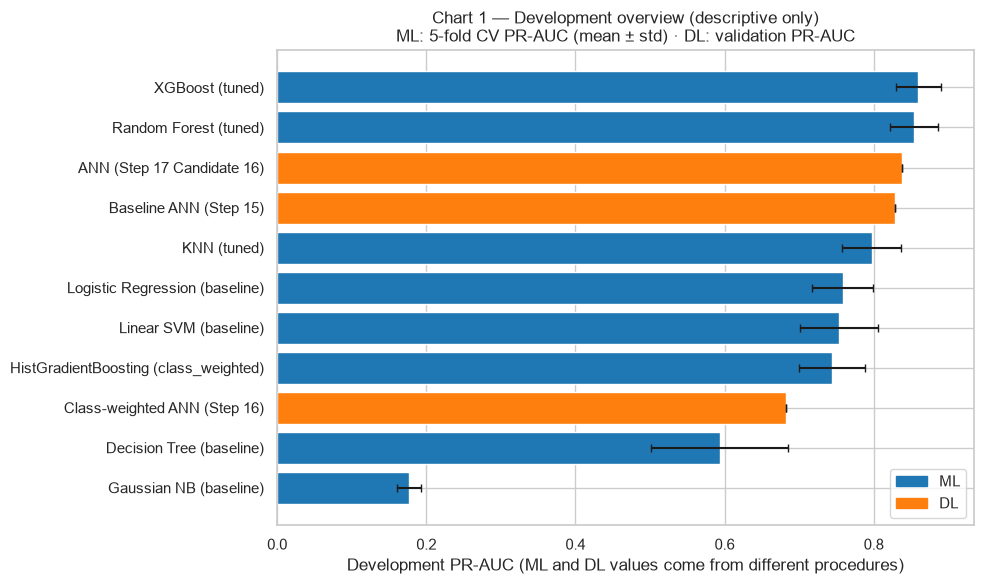

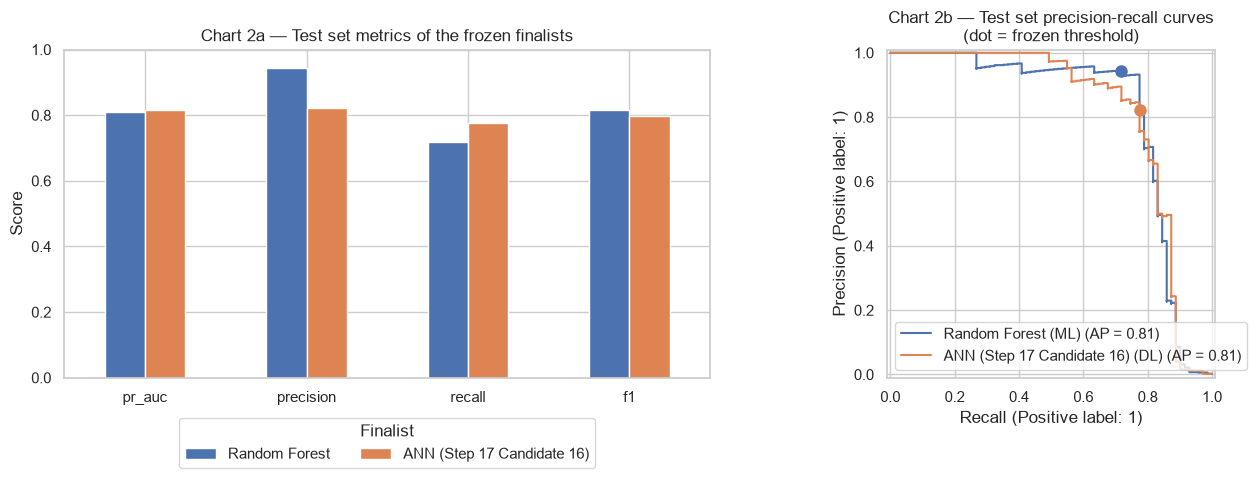

,model,family,threshold,validation_pr_auc,test_pr_auc,test_precision,test_recall,test_f1,test_roc_auc,test_accuracy,test_confusion_matrix
0,Random Forest,ML,0.7549,0.8441,0.8100,0.9444,0.7183,0.8160,0.9745,0.9995,"[[42485, 3], [20, 51]]"
1,ANN (Step 17 Candidate 16),DL,0.3364,0.8380,0.8149,0.8209,0.7746,0.7971,0.9669,0.9993,"[[42476, 12], [16, 55]]"


Higher test pr_auc: ANN (Step 17 Candidate 16) (0.8149)
Higher test precision: Random Forest (0.9444)
Higher test recall: ANN (Step 17 Candidate 16) (0.7746)
Higher test f1: Random Forest (0.8160)
Higher test roc_auc: Random Forest (0.9745)

Final model under the predefined primary-metric rule (higher test PR-AUC): ANN (Step 17 Candidate 16) (DL)
Test PR-AUC 0.8149 vs 0.8100 for Random Forest (difference 0.0049)


In [36]:
from matplotlib.patches import Patch

tuned_cv = tuning_df.set_index("model")
development_rows = []
for _, row in best_per_model.iterrows():
    name = row["model"]
    if name in tuned_cv.index:
        development_rows.append({"model": f"{name} (tuned)", "family": "ML", "pr_auc": tuned_cv.loc[name, "tuned_pr_auc_mean"], "std": tuned_cv.loc[name, "tuned_pr_auc_std"]})
    else:
        development_rows.append({"model": f"{name} ({row['strategy']})", "family": "ML", "pr_auc": row["pr_auc_mean"], "std": row["pr_auc_std"]})
for _, row in ann_summary.iterrows():
    development_rows.append({"model": row["model"], "family": "DL", "pr_auc": row["pr_auc"], "std": 0.0})
development_df = pd.DataFrame(development_rows).sort_values("pr_auc").reset_index(drop=True)

family_colors = {"ML": "tab:blue", "DL": "tab:orange"}
plt.figure(figsize=(10, 6))
plt.barh(development_df["model"], development_df["pr_auc"], xerr=development_df["std"], capsize=3, color=development_df["family"].map(family_colors))
plt.title("Chart 1 — Development overview (descriptive only)\nML: 5-fold CV PR-AUC (mean ± std) · DL: validation PR-AUC")
plt.xlabel("Development PR-AUC (ML and DL values come from different procedures)")
plt.legend(handles=[Patch(color=color, label=family) for family, color in family_colors.items()], loc="lower right")
plt.tight_layout()
plt.show()

metrics = ["pr_auc", "precision", "recall", "f1"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
test_results_df.set_index("model")[metrics].T.plot(kind="bar", ax=axes[0])
axes[0].set_title("Chart 2a — Test set metrics of the frozen finalists")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Finalist", loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
for _, row in test_results_df.iterrows():
    display_pr = PrecisionRecallDisplay.from_predictions(y_test, test_scores[row["model"]], name=f"{row['model']} ({row['family']})", ax=axes[1])
    axes[1].plot(row["recall"], row["precision"], marker="o", markersize=8, color=display_pr.line_.get_color())
axes[1].set_title("Chart 2b — Test set precision-recall curves\n(dot = frozen threshold)")
plt.tight_layout()
plt.show()

final_comparison = test_results_df[["model", "family", "threshold"]].copy()
final_comparison["validation_pr_auc"] = [frozen_finalists[name]["validation_pr_auc"] for name in final_comparison["model"]]
for column in ["pr_auc", "precision", "recall", "f1", "roc_auc", "accuracy"]:
    final_comparison[f"test_{column}"] = test_results_df[column]
final_comparison["test_confusion_matrix"] = [matrix.tolist() for matrix in test_results_df["confusion_matrix"]]
display(final_comparison.round(4))

for metric in ["pr_auc", "precision", "recall", "f1", "roc_auc"]:
    leader = test_results_df.loc[test_results_df[metric].idxmax()]
    print(f"Higher test {metric}: {leader['model']} ({leader[metric]:.4f})")

final_row = test_results_df.loc[test_results_df["pr_auc"].idxmax()]
other_row = test_results_df.loc[test_results_df["pr_auc"].idxmin()]
print(f"\nFinal model under the predefined primary-metric rule (higher test PR-AUC): {final_row['model']} ({final_row['family']})")
print(f"Test PR-AUC {final_row['pr_auc']:.4f} vs {other_row['pr_auc']:.4f} for {other_row['model']} (difference {final_row['pr_auc'] - other_row['pr_auc']:.4f})")

### Step 22 insights
- **Development overview (Chart 1, descriptive):** the highest development scores are XGBoost (tuned, CV PR-AUC 0.860) and Random Forest (tuned, 0.854), followed by the tuned ANN (validation PR-AUC 0.838) and the baseline ANN (0.829). These ML and DL values come from different procedures (5-fold CV vs a single validation set) and are not used to decide between ML and DL.
- **Test comparison (Chart 2, authoritative):** on the same test set, the tuned ANN has a test PR-AUC of **0.815** and Random Forest **0.810**, a difference of 0.005. Their test precision-recall curves are very close, with average precision of about 0.81 for both, and the curves cross several times.
- At the frozen thresholds, the ANN is ahead on recall (0.775 vs 0.718; 55 vs 51 of 71 frauds detected), while Random Forest is ahead on precision (0.944 vs 0.821; 3 vs 12 false alarms), F1 (0.816 vs 0.797) and ROC-AUC (0.975 vs 0.967).
- The **ANN (Step 17 Candidate 16)** is selected as the final deployment model: it has the higher test PR-AUC, the primary metric, and the higher recall, which matches the aim of detecting as many fraudulent transactions as possible. This comes at the cost of 9 more false alarms than Random Forest.
- This conclusion is limited to this test set: the PR-AUC gap is small, the test set contains only 71 frauds, and precision, recall and F1 do not all favour the same model, so the result does not show that DL is generally better than ML for this problem.

----

## Step 23 : Final best model selection
**Objective:** Formally record the deployment model selected in Step 22 under the predefined primary-metric rule (higher test PR-AUC), together with everything needed to use it: the model, its input scaler, the frozen decision threshold, the fixed feature order, its hyperparameters and its test results. The recorded configuration is then applied to the raw test features (feature reordering → scaling → prediction → threshold) to confirm that it reproduces the Step 21 test results exactly. No model is selected again, retrained or retuned. The runner-up is shown for transparency.

In [37]:
deployment_name = final_row["model"]
deployment = frozen_finalists[deployment_name]

deployment_config = {
    "model_name": deployment_name,
    "family": deployment["family"],
    "model": deployment["model"],
    "scaler": ann_scaler if deployment["family"] == "DL" else None,
    "input_scaling": deployment["input_scaling"],
    "threshold": deployment["threshold"],
    "feature_columns": feature_columns,
    "hyperparameters": deployment["hyperparameters"],
    "test_results": {metric: final_row[metric] for metric in ["pr_auc", "precision", "recall", "f1", "roc_auc", "accuracy"]},
    "test_confusion_matrix": final_row["confusion_matrix"].tolist(),
}

X_check = X_test[deployment_config["feature_columns"]]
if deployment_config["family"] == "DL":
    check_scores = deployment_config["model"].predict(deployment_config["scaler"].transform(X_check), verbose=0).ravel()
else:
    check_scores = get_scores(deployment_config["model"], X_check)
check_predictions = (check_scores >= deployment_config["threshold"]).astype(int)
check_matrix = confusion_matrix(y_test, check_predictions).tolist()
check_pr_auc = average_precision_score(y_test, check_scores)

print("Deployment model:", deployment_config["model_name"], f"({deployment_config['family']})")
print("Input scaling:", deployment_config["input_scaling"])
print(f"Decision threshold: {deployment_config['threshold']:.4f}")
print(f"Features ({len(deployment_config['feature_columns'])}, fixed order): {deployment_config['feature_columns']}")
print("Hyperparameters:", deployment_config["hyperparameters"])
print(f"Reproduction check: test PR-AUC {check_pr_auc:.4f} (match: {np.isclose(check_pr_auc, deployment_config['test_results']['pr_auc'])})")
print(f"Reproduction check: test confusion matrix {check_matrix} (match: {check_matrix == deployment_config['test_confusion_matrix']})")

runner_up = test_results_df.loc[test_results_df["model"] != deployment_name].iloc[0]
summary = pd.DataFrame([
    {"role": "deployment model", "model": deployment_name, "family": deployment_config["family"], **deployment_config["test_results"]},
    {"role": "runner-up", "model": runner_up["model"], "family": runner_up["family"], **{metric: runner_up[metric] for metric in ["pr_auc", "precision", "recall", "f1", "roc_auc", "accuracy"]}},
])
display(summary.round(4))

Deployment model: ANN (Step 17 Candidate 16) (DL)
Input scaling: RobustScaler fitted in Step 15 (ann_scaler)
Decision threshold: 0.3364
Features (30, fixed order): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Hyperparameters: {'learning_rate': 0.001, 'hidden_units': (32, 16), 'fraud_weight': 1.0, 'dropout': 0.2, 'batch_size': 1024}
Reproduction check: test PR-AUC 0.8149 (match: True)
Reproduction check: test confusion matrix [[42476, 12], [16, 55]] (match: True)


,role,model,family,pr_auc,precision,recall,f1,roc_auc,accuracy
0,deployment model,ANN (Step 17 Candidate 16),DL,0.8149,0.8209,0.7746,0.7971,0.9669,0.9993
1,runner-up,Random Forest,ML,0.8100,0.9444,0.7183,0.8160,0.9745,0.9995


### Step 23 insights
- The final deployment model is the **ANN (Step 17 Candidate 16)**: two hidden layers (32 and 16 units) with dropout 0.2, trained with learning rate 0.001 and batch size 1024 without class weighting, used with a decision threshold of **0.3364**.
- To use the model on new transactions, three recorded components are needed together: the fixed order of the 30 input features (`Time`, `V1`–`V28`, `Amount`), the RobustScaler fitted on the training data (`ann_scaler`), and the decision threshold.
- Applying these recorded components to the raw test features reproduces the Step 21 test results exactly (PR-AUC 0.8149, confusion matrix [[42476, 12], [16, 55]]), confirming that the deployment configuration is complete and consistent.
- With this configuration, the model detected 55 of the 71 test frauds (recall 0.775) and raised 12 false alarms among 42,488 legitimate test transactions (precision 0.821).
- The runner-up, Random Forest with SMOTE, had a slightly lower test PR-AUC (0.810) but higher precision (0.944), F1 (0.816) and ROC-AUC (0.975), as reported in Step 22.

----

## Step 24 : Final model interpretation & conclusions
**Objective:** Summarise the project's findings, explain why the deployment model was selected, describe how class-imbalance handling and the decision threshold affected the results, and state the limitations of the data and the evaluation. All figures come from the outputs of Steps 1–23; no new modelling is done.

In [38]:
def cv_pr_auc(results, model, strategy):
    row = results[(results["model"] == model) & (results["strategy"] == strategy)]
    return row["pr_auc_mean"].iloc[0]

ml_strategy = stage2_best.set_index("model").loc[best_ml_name, "strategy"]
test_pr_auc = test_results_df.set_index("model")["pr_auc"]

journey = pd.DataFrame([
    {"model": best_ml_name, "stage": "Baseline (Step 9)", "evaluated_on": "5-fold CV", "pr_auc": cv_pr_auc(stage1_df, best_ml_name, "baseline")},
    {"model": best_ml_name, "stage": f"Best imbalance strategy: {ml_strategy} (Step 12)", "evaluated_on": "5-fold CV", "pr_auc": cv_pr_auc(stage2_df, best_ml_name, ml_strategy)},
    {"model": best_ml_name, "stage": "Tuned (Step 13)", "evaluated_on": "5-fold CV", "pr_auc": tuning_df.set_index("model").loc[best_ml_name, "tuned_pr_auc_mean"]},
    {"model": best_ml_name, "stage": "Selected ML finalist (Step 14)", "evaluated_on": "validation", "pr_auc": frozen_finalists[best_ml_name]["validation_pr_auc"]},
    {"model": best_ml_name, "stage": "Final evaluation (Step 21)", "evaluated_on": "test", "pr_auc": test_pr_auc[best_ml_name]},
    {"model": best_dl_name, "stage": "Baseline ANN (Step 15)", "evaluated_on": "validation", "pr_auc": baseline_ann_val["pr_auc"]},
    {"model": best_dl_name, "stage": "Tuned ANN (Step 17)", "evaluated_on": "validation", "pr_auc": best_ann_val["pr_auc"]},
    {"model": best_dl_name, "stage": "Final evaluation (Step 21)", "evaluated_on": "test", "pr_auc": test_pr_auc[best_dl_name]},
])
display(journey.round(4))

,model,stage,evaluated_on,pr_auc
0,Random Forest,Baseline (Step 9),5-fold CV,0.8363
1,Random Forest,Best imbalance strategy: smote (Step 12),5-fold CV,0.8492
2,Random Forest,Tuned (Step 13),5-fold CV,0.8543
3,Random Forest,Selected ML finalist (Step 14),validation,0.8441
4,Random Forest,Final evaluation (Step 21),test,0.8100
5,ANN (Step 17 Candidate 16),Baseline ANN (Step 15),validation,0.8288
6,ANN (Step 17 Candidate 16),Tuned ANN (Step 17),validation,0.8380
7,ANN (Step 17 Candidate 16),Final evaluation (Step 21),test,0.8149


### Conclusions

**Approach in brief**
- 1,081 exact duplicate rows were removed, leaving 283,726 transactions (473 frauds, 0.167%). The data was split 70/15/15 into training, validation and test sets, stratified on `Class`.
- PR-AUC was used as the primary metric throughout because of the extreme class imbalance; a model that always predicts non-fraud reaches 99.83% accuracy while detecting no fraud (Step 8).
- Eight ML families were compared with 5-fold stratified CV, imbalance strategies (class weighting, undersampling, SMOTE) were tested, the three strongest configurations were tuned, and the best ML model was selected on the validation set. ANN variants were trained, weighted and tuned using the validation set for early stopping and selection.
- For both finalists, a decision threshold was chosen by maximising validation F1, the models were frozen, and the test set was used once for the final comparison.

**ML vs DL result**
- On the test set, the tuned ANN reached a PR-AUC of 0.815 and the best ML model (Random Forest with SMOTE) 0.810. The ANN also detected more frauds (55 vs 51 of 71; recall 0.775 vs 0.718). Since the aim of the project is to detect as many fraudulent transactions as possible, and the ANN is ahead on both PR-AUC and recall, the ANN is selected as the deployment model.
- Random Forest was ahead on precision (0.944 vs 0.821), F1 (0.816 vs 0.797) and ROC-AUC (0.975 vs 0.967), while the ANN was ahead on PR-AUC and recall (0.775 vs 0.718).
- The PR-AUC gap of 0.005 is small and limited to this test set, so the result does not show that DL is generally better than ML for this problem.

**Effect of imbalance handling**
- Class weighting helped the boosting models (XGBoost CV PR-AUC 0.758 → 0.851, HistGradientBoosting 0.635 → 0.744) but not the linear models, where recall rose to about 0.91 while precision fell to 0.056 (Logistic Regression) and 0.068 (Linear SVM).
- SMOTE improved Random Forest (0.836 → 0.849) and XGBoost (0.851 class-weighted → 0.853), and within the configurations sampled during tuning, a SMOTE ratio of 0.1 gave the best CV PR-AUC for both. SMOTE did not suit KNN (PR-AUC 0.528).
- Random undersampling gave the lowest PR-AUC for all three selected families; each training fold kept only about 530 rows, discarding most non-fraud observations and likely contributing to the weaker performance.
- For the ANN, fully balanced class weights lowered validation PR-AUC from 0.829 to 0.682, and milder fraud weights (5 and 25) did not beat the unweighted network, so the final ANN uses no class weighting.

**Error behaviour of the deployment model (test set)**
- The ANN detected 55 of the 71 test frauds and missed 16, and raised 12 false alarms among 42,488 legitimate transactions.
- Random Forest, at its own frozen threshold, would have detected 51 frauds, missed 20 and raised 3 false alarms. The two models therefore offer a trade-off between catching more fraud and raising fewer false alarms.

**Limitations**
- There are only 71 frauds in each of validation and test, so small performance differences should be interpreted cautiously and are not sufficient to establish a robust advantage.
- The validation set was used for model selection, early stopping and threshold tuning, so validation scores are optimistic; both finalists scored lower on the test set (Random Forest 0.844 → 0.810, ANN 0.838 → 0.815).
- Decision thresholds were selected by maximising validation F1 because no business cost ratio, target recall or acceptable false-positive rate was defined. This produces a balanced precision–recall operating point rather than explicitly maximising recall; a recall-prioritised threshold would produce a different trade-off.
- `Time` is measured in seconds from the first transaction in this dataset, so it has no meaning outside it; a production system would need a properly defined time feature.
- `V1`–`V28` are anonymised PCA components, so the influence of individual features cannot be interpreted in business terms.
- 1,081 exact duplicate rows were removed without transaction IDs to confirm whether they were errors or genuine repeated transactions.
- 48 rows with exact whole-number PCA values (including `V3 = 4232` and `V9 = 1221`) were kept, because it could not be established whether they are errors.
- The data covers two days of transactions by European cardholders in September 2013, so results may not carry over to other periods or populations.

----

## Step 25 : Save deployment artifacts
**Objective:** Save the deployment model (ANN, Step 23) and everything needed to use it and present its results: the Keras model, the RobustScaler fitted on the training data, a metadata file (model name, decision threshold, feature order, hyperparameters, test results and library versions), the final ML-vs-DL comparison table, the test precision-recall curve points of both finalists and a small fixed demo sample of test transactions. The saved model, scaler and metadata are then reloaded from disk and applied to the unchanged original test set, confirming that the saved deployment artifacts reproduce the Step 23 results exactly. The demo sample contains 10 fraud and 40 non-fraud rows drawn only from the test set; this demo sample is deliberately enriched with fraud cases for demonstration and does not represent the dataset's natural fraud prevalence. For the precision-recall curves, only the first and last point at each recall level are kept, which reproduces the same curves with far fewer rows. The model output is reported as a fraud score rather than a probability, because the scores have not been calibrated.

In [39]:
import os
import json
import joblib
import sklearn

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

model_path = os.path.join(ARTIFACT_DIR, "fraud_ann.keras")
scaler_path = os.path.join(ARTIFACT_DIR, "ann_scaler.joblib")
metadata_path = os.path.join(ARTIFACT_DIR, "deployment_metadata.json")

deployment_config["model"].save(model_path)
joblib.dump(deployment_config["scaler"], scaler_path)

demo_note = "This demo sample is deliberately enriched with fraud cases for demonstration and does not represent the dataset's natural fraud prevalence."

metadata = {
    "model_name": deployment_config["model_name"],
    "family": deployment_config["family"],
    "threshold": float(deployment_config["threshold"]),
    "feature_columns": deployment_config["feature_columns"],
    "hyperparameters": deployment_config["hyperparameters"],
    "test_results": {metric: float(value) for metric, value in deployment_config["test_results"].items()},
    "test_confusion_matrix": deployment_config["test_confusion_matrix"],
    "demo_sample_note": demo_note,
    "random_state": RANDOM_STATE,
    "library_versions": {
        "tensorflow": tf.__version__,
        "scikit-learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}
with open(metadata_path, "w") as file:
    json.dump(metadata, file, indent=2)

final_comparison.to_csv(os.path.join(ARTIFACT_DIR, "final_comparison.csv"), index=False)

curve_tables = []
for name, scores in test_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    curve = pd.DataFrame({"model": name, "precision": precision, "recall": recall})
    keep = ~curve.duplicated("recall", keep="first") | ~curve.duplicated("recall", keep="last")
    curve_tables.append(curve[keep])
pd.concat(curve_tables).to_csv(os.path.join(ARTIFACT_DIR, "test_pr_curves.csv"), index=False)

test_data = X_test.copy()
test_data["Class"] = y_test
demo_frauds = test_data[test_data["Class"] == 1].sample(10, random_state=RANDOM_STATE)
demo_non_frauds = test_data[test_data["Class"] == 0].sample(40, random_state=RANDOM_STATE)
demo_sample = pd.concat([demo_frauds, demo_non_frauds]).sample(frac=1, random_state=RANDOM_STATE)
demo_sample.to_csv(os.path.join(ARTIFACT_DIR, "test_sample.csv"), index=False)

loaded_model = tf.keras.models.load_model(model_path, compile=False)
loaded_scaler = joblib.load(scaler_path)
with open(metadata_path) as file:
    loaded_metadata = json.load(file)

reload_scores = loaded_model.predict(loaded_scaler.transform(X_test[loaded_metadata["feature_columns"]]), verbose=0).ravel()
reload_predictions = (reload_scores >= loaded_metadata["threshold"]).astype(int)
reload_matrix = confusion_matrix(y_test, reload_predictions).tolist()
reload_pr_auc = average_precision_score(y_test, reload_scores)
print(f"Reload check: test PR-AUC {reload_pr_auc:.4f} (match: {np.isclose(reload_pr_auc, loaded_metadata['test_results']['pr_auc'])})")
print(f"Reload check: test confusion matrix {reload_matrix} (match: {reload_matrix == loaded_metadata['test_confusion_matrix']})")

demo_scores = loaded_model.predict(loaded_scaler.transform(demo_sample[loaded_metadata["feature_columns"]]), verbose=0).ravel()
demo_view = demo_sample[["Amount", "Class"]].copy()
demo_view["fraud_score"] = demo_scores
demo_view["predicted_class"] = (demo_scores >= loaded_metadata["threshold"]).astype(int)
print(f"\nDemo sample: {len(demo_sample)} test rows ({demo_sample['Class'].sum()} frauds). {demo_note}")
print("Demo predictions matching actual class:", (demo_view["predicted_class"] == demo_view["Class"]).sum(), "of", len(demo_view))
display(demo_view[demo_view["Class"] == 1].round(4))

for file_name in sorted(os.listdir(ARTIFACT_DIR)):
    print(f"{file_name}: {os.path.getsize(os.path.join(ARTIFACT_DIR, file_name)) / 1024:.1f} KB")

Reload check: test PR-AUC 0.8149 (match: True)
Reload check: test confusion matrix [[42476, 12], [16, 55]] (match: True)

Demo sample: 50 test rows (10 frauds). This demo sample is deliberately enriched with fraud cases for demonstration and does not represent the dataset's natural fraud prevalence.
Demo predictions matching actual class: 45 of 50


,Amount,Class,fraud_score,predicted_class
112392,45.03,1,0.0000,0
42979,273.01,1,0.9801,1
10442,3.79,1,0.0276,0
145246,451.27,1,0.0127,0
254457,4.97,1,0.7573,1
107830,0.76,1,0.0000,0
6860,1.00,1,0.8700,1
248322,1096.99,1,0.0000,0
200883,130.21,1,0.7407,1
42588,118.30,1,0.9704,1


ann_scaler.joblib: 1.4 KB
deployment_metadata.json: 1.2 KB
final_comparison.csv: 0.5 KB
fraud_ann.keras: 47.5 KB
test_pr_curves.csv: 9.3 KB
test_sample.csv: 17.9 KB


### Step 25 insights
- Six deployment artifacts were saved in the `artifacts/` folder, about 78 KB in total: the ANN model (47.5 KB), the fitted RobustScaler, a metadata file, the final ML-vs-DL comparison table, the test precision-recall curve points and the demo sample.
- Reloading the saved model, scaler and metadata from disk and applying them to the unchanged original test set reproduces the Step 23 results exactly (PR-AUC 0.8149, confusion matrix [[42476, 12], [16, 55]]).
- The metadata stores the decision threshold at full precision (0.3363977…), the fixed order of the 30 input features, the model's hyperparameters, its test results and the library versions used (TensorFlow 2.16.2, scikit-learn 1.9.1, pandas 3.0.6, NumPy 1.26.4).
- The precision-recall curve file keeps 176 points instead of about 67,000 while reproducing the same curves, reducing it from about 4 MB to 9.3 KB.
- In the demo sample of 50 test transactions, all 40 non-fraud transactions are classified correctly and 5 of the 10 frauds are flagged, with fraud scores between 0.74 and 0.98. The 5 missed frauds have scores between 0.0000 and 0.0276, well below the 0.3364 threshold.
- The demo detection rate (5 of 10) is lower than on the full test set (55 of 71, recall 0.775), which reflects the small size of the demo sample. The sample was not redrawn.
- The model output is reported as a fraud score rather than a probability, because the scores have not been calibrated.

----